<a href="https://colab.research.google.com/github/apurvharsh/MENTAL-HEALTH/blob/main/sITAR_RESEARCH_PAPER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn tensorflow scipy
print('✅ All libraries installed.')

✅ All libraries installed.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import ttest_rel
import warnings, os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

sns.set_style('whitegrid')
os.makedirs('/content/outputs', exist_ok=True)
print(f'✅ Imports done | TensorFlow {tf.__version__}')

✅ Imports done | TensorFlow 2.19.0


In [ ]:
from google.colab import files
print('👆 Upload your file ;) csv')
uploaded = files.upload()

👆 Upload your file ;) csv


Saving sitar_raga_data set.csv to sitar_raga_data set.csv


In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')
print(f'\nRaga distribution:')
print(df['Raga_Listened'].value_counts().to_string())
print(f'\nAge distribution:')
print(df['Age_Group'].value_counts().to_string())
print(f'\nGender distribution:')
print(df['Gender'].value_counts().to_string())
df.head(5)

✅ Dataset loaded: 1500 rows × 33 columns

Columns: ['Participant_ID', 'Email', 'Consent', 'Age_Group', 'Gender', 'Occupation', 'Prior_Classical_Music_Exposure', 'Raga_Listened', 'Time_of_Listening', 'Duration', 'Listening_Mode', 'Environment', 'Stress_Before', 'Stress_After', 'Stress_Reduction', 'Anxiety_Before', 'Anxiety_After', 'Anxiety_Reduction', 'Mood_Before', 'Mood_After', 'Mood_Improvement', 'Focus_Before', 'Focus_After', 'Focus_Improvement', 'Calmness_Before', 'Calmness_After', 'Calmness_Improvement', 'Felt_Calmer_After', 'Raga_More_Calming', 'Sitar_Effectiveness', 'Would_Reuse_Sitar', 'One_Word_Feeling', 'Additional_Comments']

Raga distribution:
Raga_Listened
Raga Bhairavi (Morning)    756
Raga Yaman (Evening)       744

Age distribution:
Age_Group
18-25       851
Below 18    306
26-40       242
Above 40    101

Gender distribution:
Gender
Female               707
Male                 662
Prefer not to say    131


,Participant_ID,Email,Consent,Age_Group,Gender,Occupation,Prior_Classical_Music_Exposure,Raga_Listened,Time_of_Listening,Duration,...,Focus_Improvement,Calmness_Before,Calmness_After,Calmness_Improvement,Felt_Calmer_After,Raga_More_Calming,Sitar_Effectiveness,Would_Reuse_Sitar,One_Word_Feeling,Additional_Comments
0,P0001,pankaj1825@gmail.com,Yes,Above 40,Female,Student,Yes,Raga Bhairavi (Morning),Morning (4-9 AM),10 minutes,...,2,1,4,3,Yes,Both equally,4,Yes,Peaceful,A unique and calming experience.
1,P0002,sunita3658@yahoo.com,Yes,18-25,Female,Student,No,Raga Bhairavi (Morning),Morning (4-9 AM),10 minutes,...,3,1,4,3,Yes,Not sure,4,Yes,Refreshed,I enjoyed the morning raga very much.
2,P0003,preeti8936@gmail.com,Yes,18-25,Female,Student,Occasionally,Raga Bhairavi (Morning),Morning (4-9 AM),15 minutes,...,2,2,4,2,Yes,Raga Bhairavi (Morning),5,Yes,Calm,Reduced my anxiety noticeably.
3,P0004,rohit489@gmail.com,Yes,26-40,Male,Student,Occasionally,Raga Yaman (Evening),Evening (5-9 PM),15 minutes,...,2,1,5,4,Yes,Raga Yaman (Evening),5,Yes,Serene,Will definitely listen again.
4,P0005,ravi8280@rediffmail.com,Yes,18-25,Female,Student,No,Raga Yaman (Evening),Evening (5-9 PM),10 minutes,...,3,1,4,3,Yes,Not sure,4,Yes,Refreshed,Very soothing experience.


In [ ]:
# Install audio processing libraries
!pip install -q librosa soundfile pydub
print('✅ Audio libraries installed.')

✅ Audio libraries installed.


In [ ]:
from google.colab import files as colab_files

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Upload 1 of 2 — Raga Bhairavi (Morning)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('='*55)
print('  📁  UPLOAD 1 of 2')
print('  🎵  Raga Bhairavi (Morning) — MP4 file')
print('='*55)
upload_bhairavi = colab_files.upload()

bhairavi_file = list(upload_bhairavi.keys())[0]
print(f'\n  ✅ Raga Bhairavi file received: {bhairavi_file}')


  📁  UPLOAD 1 of 2
  🎵  Raga Bhairavi (Morning) — MP4 file


Saving ytmp3free.cc_raag-bhairavi-ektaal-youtubemp3free.org.mp3 to ytmp3free.cc_raag-bhairavi-ektaal-youtubemp3free.org.mp3

  ✅ Raga Bhairavi file received: ytmp3free.cc_raag-bhairavi-ektaal-youtubemp3free.org.mp3


In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  Upload 2 of 2 — Raga Yaman (Evening)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('='*55)
print('  📁  UPLOAD 2 of 2')
print('  🎵  Raga Yaman (Evening) — MP4 file')
print('='*55)
upload_yaman = colab_files.upload()

yaman_file = list(upload_yaman.keys())[0]
print(f'\n  ✅ Raga Yaman file received: {yaman_file}')

# ── Final raga → file mapping ─────────────────────────────
import os
raga_file_map = {
    'Raga Bhairavi (Morning)': bhairavi_file,
    'Raga Yaman (Evening)'   : yaman_file,
}

print()
print('='*55)
print('  🗂️   FILE MAPPING CONFIRMED')
print('='*55)
for raga, fname in raga_file_map.items():
    size_kb = len(upload_bhairavi.get(fname, upload_yaman.get(fname, b''))) / 1024
    print(f'  ✅  {raga}')
    print(f'       └─ {fname}  ({size_kb:.1f} KB)')
print()
print('  ▶️  Run next cell to convert MP4 → WAV')

  📁  UPLOAD 2 of 2
  🎵  Raga Yaman (Evening) — MP4 file


Saving ytmp3free.cc_yaman-drut-yaman-saathsaath-2022-youtubemp3free.org.mp3 to ytmp3free.cc_yaman-drut-yaman-saathsaath-2022-youtubemp3free.org.mp3

  ✅ Raga Yaman file received: ytmp3free.cc_yaman-drut-yaman-saathsaath-2022-youtubemp3free.org.mp3

  🗂️   FILE MAPPING CONFIRMED
  ✅  Raga Bhairavi (Morning)
       └─ ytmp3free.cc_raag-bhairavi-ektaal-youtubemp3free.org.mp3  (8186.3 KB)
  ✅  Raga Yaman (Evening)
       └─ ytmp3free.cc_yaman-drut-yaman-saathsaath-2022-youtubemp3free.org.mp3  (9877.5 KB)

  ▶️  Run next cell to convert MP4 → WAV


In [ ]:
import subprocess, shutil

os.makedirs('/content/audio', exist_ok=True)

wav_map = {}   # raga_name → wav path
for raga, mp4_path in raga_file_map.items():
    safe = raga.replace(' ','_').replace('(','').replace(')','').replace('/','_')
    wav_path = f'/content/audio/{safe}.wav'
    print(f'🔄 Converting {mp4_path} → {wav_path} ...')
    result = subprocess.run(
        ['ffmpeg', '-y', '-i', mp4_path, '-vn',
         '-acodec', 'pcm_s16le', '-ar', '22050', '-ac', '1', wav_path],
        capture_output=True, text=True
    )
    if result.returncode != 0:
        print(f'  ❌ ffmpeg error:\n{result.stderr[-500:]}')
    else:
        size_mb = os.path.getsize(wav_path) / 1e6
        print(f'  ✅ Done ({size_mb:.1f} MB)')
        wav_map[raga] = wav_path

print(f'\n✅ WAV files ready: {list(wav_map.keys())}')


🔄 Converting ytmp3free.cc_raag-bhairavi-ektaal-youtubemp3free.org.mp3 → /content/audio/Raga_Bhairavi_Morning.wav ...
  ✅ Done (23.1 MB)
🔄 Converting ytmp3free.cc_yaman-drut-yaman-saathsaath-2022-youtubemp3free.org.mp3 → /content/audio/Raga_Yaman_Evening.wav ...
  ✅ Done (27.9 MB)

✅ WAV files ready: ['Raga Bhairavi (Morning)', 'Raga Yaman (Evening)']


In [ ]:
import librosa
import librosa.display
import numpy as np
import pandas as pd

# ── Feature extraction function ──────────────────────────────────────────────
def extract_audio_features(wav_path, raga_name, sr=22050, n_mfcc=13):
    """Extract comprehensive acoustic features for a raga WAV file."""
    print(f'  Loading {raga_name} ...')
    y, sr = librosa.load(wav_path, sr=sr, mono=True)
    duration = librosa.get_duration(y=y, sr=sr)

    # ── MFCCs (13 coefficients × mean & std) ─────────────────────────────
    mfcc        = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean   = mfcc.mean(axis=1)
    mfcc_std    = mfcc.std(axis=1)

    # ── Chroma (12 pitch classes) ─────────────────────────────────────────
    chroma      = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = chroma.mean(axis=1)
    chroma_std  = chroma.std(axis=1)

    # ── Spectral features ─────────────────────────────────────────────────
    spec_centroid  = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spec_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    spec_rolloff   = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)[0]
    spec_contrast  = librosa.feature.spectral_contrast(y=y, sr=sr)

    # ── Rhythm & Tempo ────────────────────────────────────────────────────
    tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
    beat_times         = librosa.frames_to_time(beat_frames, sr=sr)
    beat_strength      = len(beat_frames) / duration if duration > 0 else 0

    # ── Zero Crossing Rate & RMS Energy ──────────────────────────────────
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    rms = librosa.feature.rms(y=y)[0]

    # ── Tonnetz (tonal centroid) ──────────────────────────────────────────
    harmonic    = librosa.effects.harmonic(y)
    tonnetz     = librosa.feature.tonnetz(y=harmonic, sr=sr)

    feat = {'Raga': raga_name, 'Duration_sec': round(duration, 2),
            'Tempo_BPM': round(float(tempo), 2),
            'Beat_Strength': round(beat_strength, 4)}

    # MFCCs
    for i in range(n_mfcc):
        feat[f'MFCC_{i+1}_mean'] = round(float(mfcc_mean[i]), 4)
        feat[f'MFCC_{i+1}_std']  = round(float(mfcc_std[i]),  4)

    # Chroma
    notes = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
    for i in range(12):
        feat[f'Chroma_{notes[i]}_mean'] = round(float(chroma_mean[i]), 4)
        feat[f'Chroma_{notes[i]}_std']  = round(float(chroma_std[i]),  4)

    # Spectral
    feat['Spectral_Centroid_mean']   = round(float(spec_centroid.mean()),  2)
    feat['Spectral_Centroid_std']    = round(float(spec_centroid.std()),   2)
    feat['Spectral_Bandwidth_mean']  = round(float(spec_bandwidth.mean()), 2)
    feat['Spectral_Bandwidth_std']   = round(float(spec_bandwidth.std()),  2)
    feat['Spectral_Rolloff_mean']    = round(float(spec_rolloff.mean()),   2)
    feat['Spectral_Rolloff_std']     = round(float(spec_rolloff.std()),    2)
    feat['Spectral_Contrast_mean']   = round(float(spec_contrast.mean()),  4)
    feat['ZCR_mean']                 = round(float(zcr.mean()),            6)
    feat['ZCR_std']                  = round(float(zcr.std()),             6)
    feat['RMS_Energy_mean']          = round(float(rms.mean()),            6)
    feat['RMS_Energy_std']           = round(float(rms.std()),             6)
    feat['Tonnetz_mean']             = round(float(tonnetz.mean()),        4)

    # Store raw arrays for plotting
    return feat, y, sr, mfcc, chroma, spec_centroid, rms

audio_features = {}
audio_raw      = {}   # raga → (y, sr, mfcc, chroma, spec_centroid, rms)

for raga, wav_path in wav_map.items():
    feat, y_raw, sr_val, mfcc_raw, chroma_raw, sc_raw, rms_raw = extract_audio_features(wav_path, raga)
    audio_features[raga] = feat
    audio_raw[raga]      = (y_raw, sr_val, mfcc_raw, chroma_raw, sc_raw, rms_raw)
    print(f'  ✅ {raga}: {len(feat)} features extracted')

audio_feat_df = pd.DataFrame(list(audio_features.values()))
audio_feat_df.to_csv('/content/outputs/audio_features.csv', index=False)
print(f'\n✅ Saved: audio_features.csv  ({audio_feat_df.shape[1]-1} features per raga)')
print(audio_feat_df[['Raga','Duration_sec','Tempo_BPM','Spectral_Centroid_mean',
                      'RMS_Energy_mean','ZCR_mean','MFCC_1_mean']].to_string(index=False))


  Loading Raga Bhairavi (Morning) ...
  ✅ Raga Bhairavi (Morning): 66 features extracted
  Loading Raga Yaman (Evening) ...
  ✅ Raga Yaman (Evening): 66 features extracted

✅ Saved: audio_features.csv  (65 features per raga)
                   Raga  Duration_sec  Tempo_BPM  Spectral_Centroid_mean  RMS_Energy_mean  ZCR_mean  MFCC_1_mean
Raga Bhairavi (Morning)        523.87     143.55                 1719.11         0.142377  0.063454    -141.9869
   Raga Yaman (Evening)        632.11     123.05                 1890.66         0.176896  0.064232    -118.5272


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


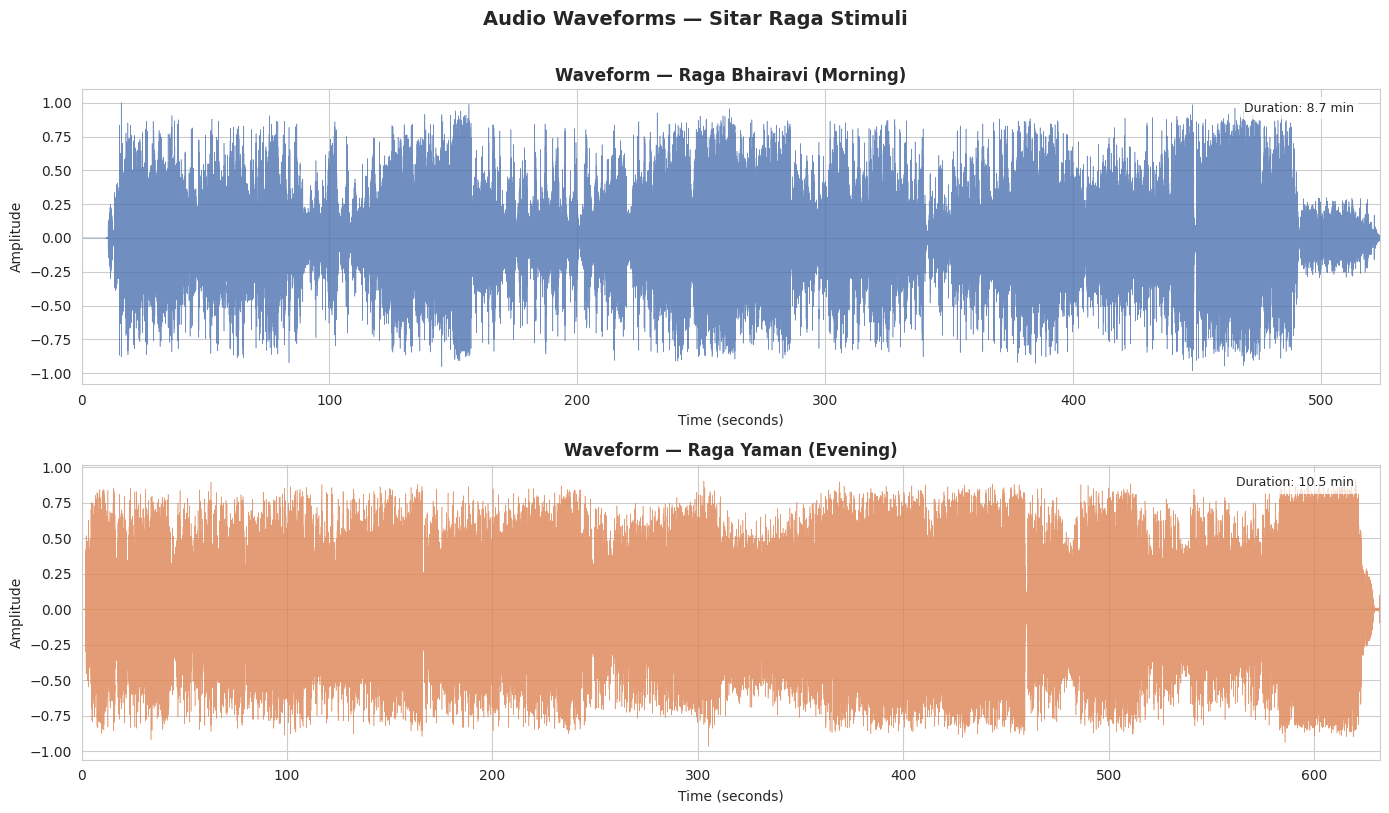

✅ Figure A1 saved: waveforms.


In [ ]:
import matplotlib.pyplot as plt
import librosa.display

# ── Figure A1: Waveforms ─────────────────────────────────────────────────────
ragas_list = list(audio_raw.keys())
colors_raga = {'Raga Bhairavi (Morning)': '#4C72B0', 'Raga Yaman (Evening)': '#DD8452'}

fig, axes = plt.subplots(len(ragas_list), 1, figsize=(14, 4 * len(ragas_list)))
if len(ragas_list) == 1: axes = [axes]

for ax, raga in zip(axes, ragas_list):
    y_r, sr_r = audio_raw[raga][0], audio_raw[raga][1]
    times = np.linspace(0, len(y_r)/sr_r, len(y_r))
    ax.plot(times, y_r, color=colors_raga.get(raga,'steelblue'), linewidth=0.4, alpha=0.8)
    ax.set_title(f'Waveform — {raga}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time (seconds)'); ax.set_ylabel('Amplitude')
    ax.set_xlim([0, len(y_r)/sr_r])
    dur = len(y_r)/sr_r
    ax.text(dur*0.98, ax.get_ylim()[1]*0.85,
            f'Duration: {dur/60:.1f} min', ha='right', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Audio Waveforms — Sitar Raga Stimuli', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/outputs/figA1_waveforms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure A1 saved: waveforms.')



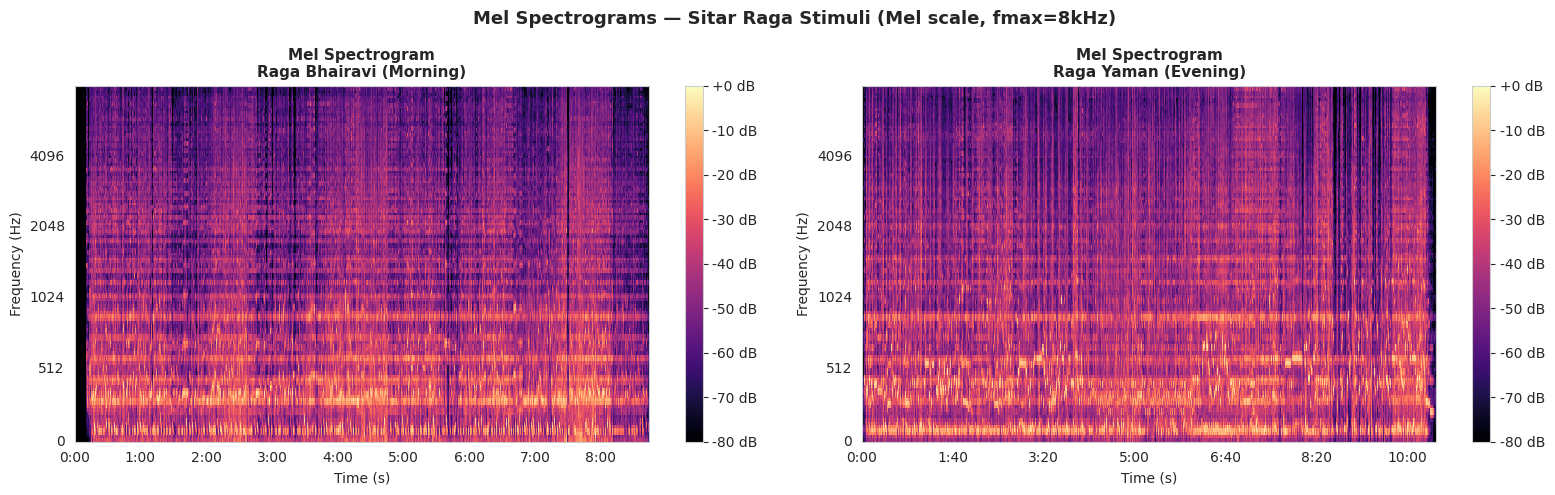

✅ Figure A2 saved: Mel spectrograms.


In [ ]:
# ── Figure A2: Mel Spectrograms ──────────────────────────────────────────────
fig, axes = plt.subplots(1, len(ragas_list), figsize=(8 * len(ragas_list), 5))
if len(ragas_list) == 1: axes = [axes]

for ax, raga in zip(axes, ragas_list):
    y_r, sr_r = audio_raw[raga][0], audio_raw[raga][1]
    S = librosa.feature.melspectrogram(y=y_r, sr=sr_r, n_mels=128, fmax=8000)
    S_dB = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_dB, sr=sr_r, x_axis='time', y_axis='mel',
                                   fmax=8000, ax=ax, cmap='magma')
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
    ax.set_title(f'Mel Spectrogram\n{raga}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Frequency (Hz)')

plt.suptitle('Mel Spectrograms — Sitar Raga Stimuli (Mel scale, fmax=8kHz)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/figA2_mel_spectrograms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure A2 saved: Mel spectrograms.')

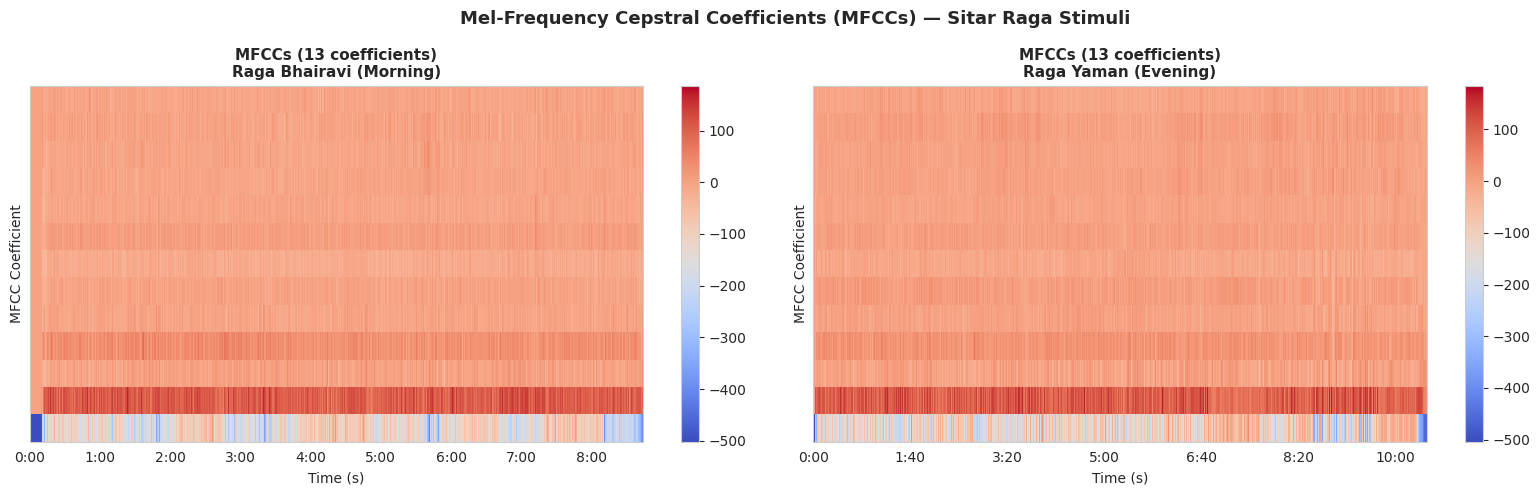

✅ Figure A3 saved: MFCC heatmaps.


In [ ]:
# ── Figure A3: MFCC Heatmaps ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(ragas_list), figsize=(8 * len(ragas_list), 5))
if len(ragas_list) == 1: axes = [axes]

for ax, raga in zip(axes, ragas_list):
    y_r, sr_r  = audio_raw[raga][0], audio_raw[raga][1]
    mfcc_r     = audio_raw[raga][2]
    img = librosa.display.specshow(mfcc_r, sr=sr_r, x_axis='time', ax=ax, cmap='coolwarm')
    fig.colorbar(img, ax=ax)
    ax.set_title(f'MFCCs (13 coefficients)\n{raga}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('MFCC Coefficient')

plt.suptitle('Mel-Frequency Cepstral Coefficients (MFCCs) — Sitar Raga Stimuli',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/figA3_mfcc_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure A3 saved: MFCC heatmaps.')


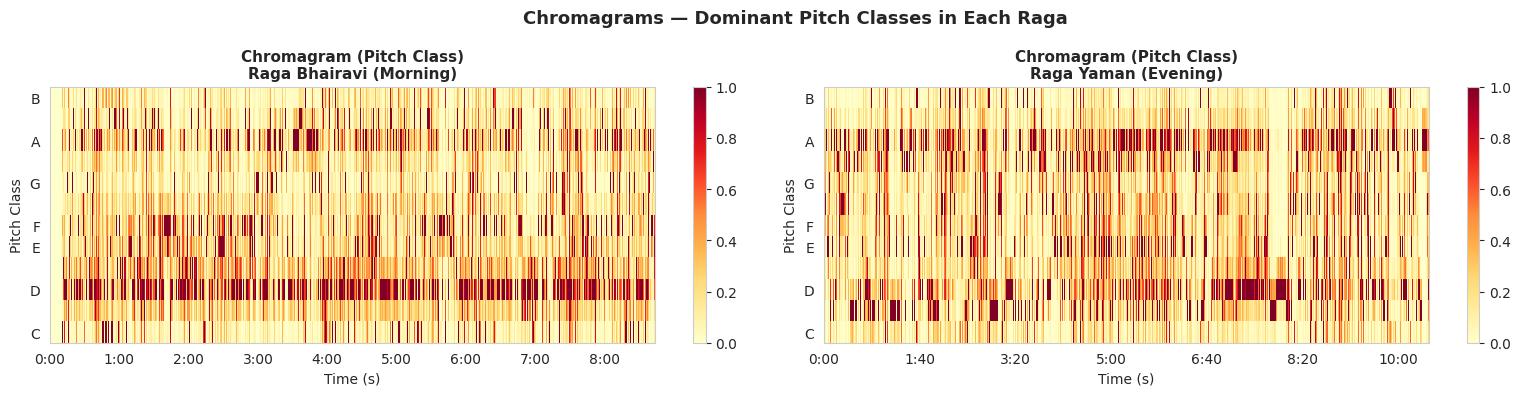

✅ Figure A4 saved: Chromagrams.


In [ ]:
# ── Figure A4: Chromagram ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(ragas_list), figsize=(8 * len(ragas_list), 4))
if len(ragas_list) == 1: axes = [axes]

for ax, raga in zip(axes, ragas_list):
    y_r, sr_r  = audio_raw[raga][0], audio_raw[raga][1]
    chroma_r   = audio_raw[raga][3]
    img = librosa.display.specshow(chroma_r, sr=sr_r, x_axis='time', y_axis='chroma',
                                   ax=ax, cmap='YlOrRd')
    fig.colorbar(img, ax=ax)
    ax.set_title(f'Chromagram (Pitch Class)\n{raga}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('Pitch Class')

plt.suptitle('Chromagrams — Dominant Pitch Classes in Each Raga',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/figA4_chromagrams.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure A4 saved: Chromagrams.')


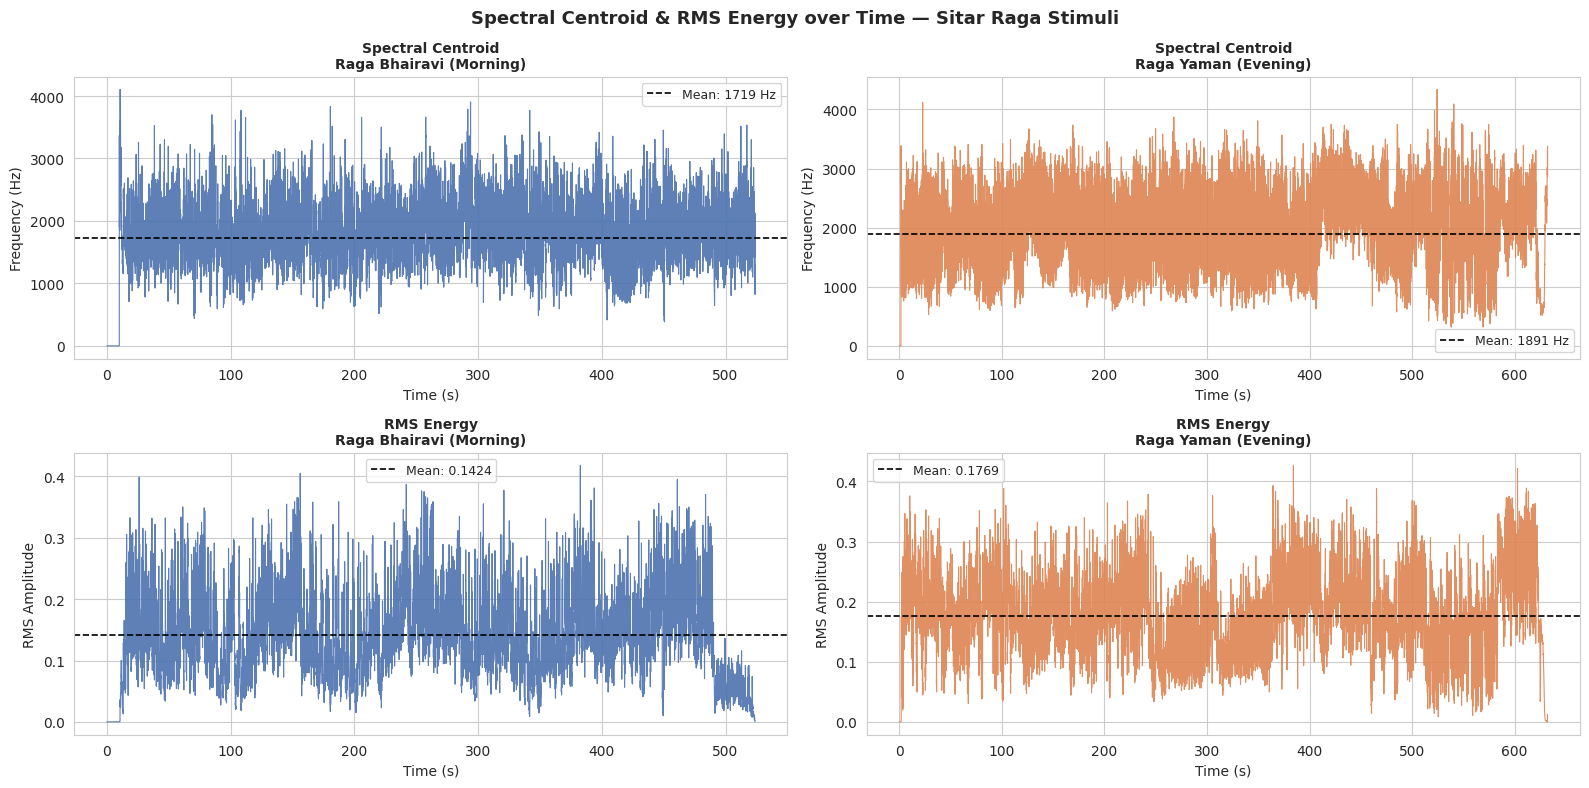

✅ Figure A5 saved: Spectral Centroid & RMS Energy.


In [ ]:
# ── Figure A5: Spectral Centroid + RMS Energy over time ──────────────────────
fig, axes = plt.subplots(2, len(ragas_list), figsize=(8 * len(ragas_list), 8))
if len(ragas_list) == 1:
    axes = axes.reshape(2, 1)

for col, raga in enumerate(ragas_list):
    y_r, sr_r  = audio_raw[raga][0], audio_raw[raga][1]
    sc_r       = audio_raw[raga][4]
    rms_r      = audio_raw[raga][5]
    t_sc  = librosa.frames_to_time(np.arange(len(sc_r)),  sr=sr_r)
    t_rms = librosa.frames_to_time(np.arange(len(rms_r)), sr=sr_r)
    clr   = colors_raga.get(raga, 'steelblue')

    axes[0, col].plot(t_sc, sc_r, color=clr, linewidth=0.8, alpha=0.9)
    axes[0, col].set_title(f'Spectral Centroid\n{raga}', fontsize=10, fontweight='bold')
    axes[0, col].set_xlabel('Time (s)'); axes[0, col].set_ylabel('Frequency (Hz)')
    axes[0, col].axhline(sc_r.mean(), color='black', linestyle='--', linewidth=1.2,
                         label=f'Mean: {sc_r.mean():.0f} Hz')
    axes[0, col].legend(fontsize=9)

    axes[1, col].plot(t_rms, rms_r, color=clr, linewidth=0.8, alpha=0.9)
    axes[1, col].set_title(f'RMS Energy\n{raga}', fontsize=10, fontweight='bold')
    axes[1, col].set_xlabel('Time (s)'); axes[1, col].set_ylabel('RMS Amplitude')
    axes[1, col].axhline(rms_r.mean(), color='black', linestyle='--', linewidth=1.2,
                         label=f'Mean: {rms_r.mean():.4f}')
    axes[1, col].legend(fontsize=9)

plt.suptitle('Spectral Centroid & RMS Energy over Time — Sitar Raga Stimuli',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/figA5_spectral_rms.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure A5 saved: Spectral Centroid & RMS Energy.')


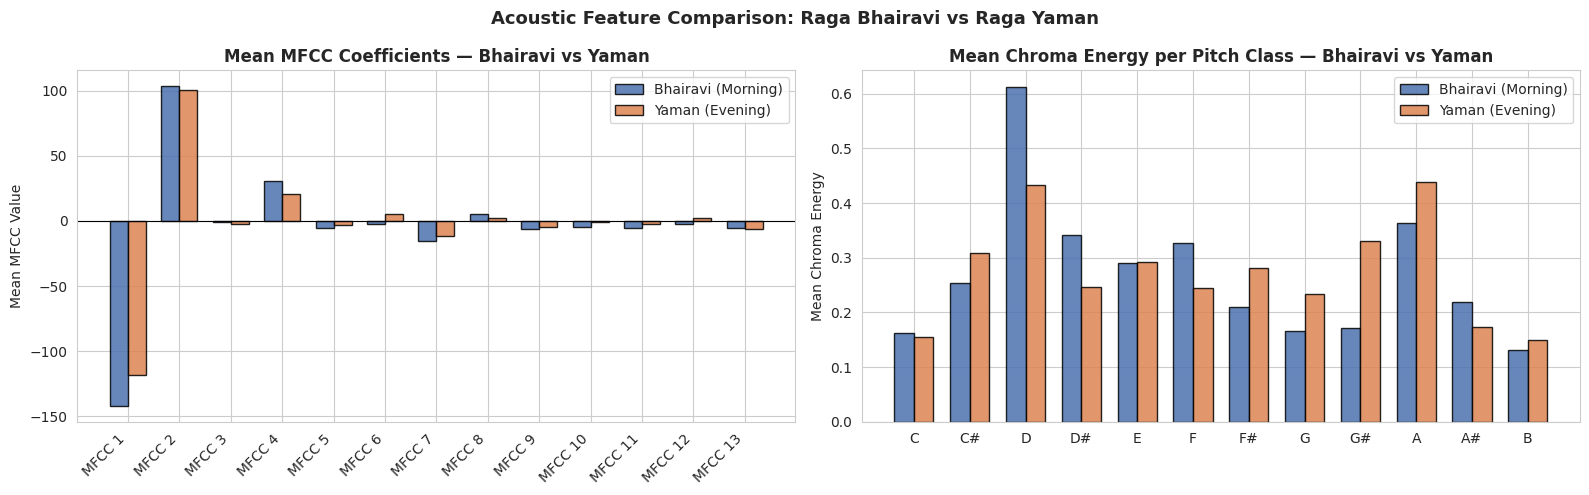

✅ Figure A6 saved: MFCC & Chroma comparison.


In [ ]:
# ── Figure A6: MFCC Mean Comparison Bar Chart (Paper-ready) ──────────────────
n_mfcc = 13
raga_names = list(audio_features.keys())
x = np.arange(n_mfcc); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MFCC means side by side
for i, raga in enumerate(raga_names):
    mfcc_means = [audio_features[raga][f'MFCC_{j+1}_mean'] for j in range(n_mfcc)]
    offset = (i - 0.5) * w
    axes[0].bar(x + offset, mfcc_means,
                w, label=raga.replace('Raga ',''), edgecolor='black',
                color=['#4C72B0','#DD8452'][i], alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'MFCC {i+1}' for i in range(n_mfcc)], rotation=45, ha='right')
axes[0].set_title('Mean MFCC Coefficients — Bhairavi vs Yaman', fontweight='bold')
axes[0].set_ylabel('Mean MFCC Value')
axes[0].legend(); axes[0].axhline(0, color='black', linewidth=0.8)

# Dominant chroma notes (mean per pitch class)
notes = ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B']
x2 = np.arange(12)
for i, raga in enumerate(raga_names):
    chroma_means = [audio_features[raga][f'Chroma_{n}_mean'] for n in notes]
    offset = (i - 0.5) * w
    axes[1].bar(x2 + offset, chroma_means,
                w, label=raga.replace('Raga ',''), edgecolor='black',
                color=['#4C72B0','#DD8452'][i], alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(notes)
axes[1].set_title('Mean Chroma Energy per Pitch Class — Bhairavi vs Yaman', fontweight='bold')
axes[1].set_ylabel('Mean Chroma Energy'); axes[1].legend()

plt.suptitle('Acoustic Feature Comparison: Raga Bhairavi vs Raga Yaman',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/figA6_mfcc_chroma_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure A6 saved: MFCC & Chroma comparison.')


In [ ]:
# ── Audio Feature Summary Table (Paper-ready) ────────────────────────────────
print('='*72)
print('  AUDIO FEATURE SUMMARY — Raga Bhairavi vs Raga Yaman')
print('='*72)
summary_keys = ['Duration_sec','Tempo_BPM','Beat_Strength',
                'Spectral_Centroid_mean','Spectral_Bandwidth_mean',
                'Spectral_Rolloff_mean','Spectral_Contrast_mean',
                'ZCR_mean','RMS_Energy_mean','Tonnetz_mean',
                'MFCC_1_mean','MFCC_2_mean','MFCC_3_mean']
print(f'  {"Feature":<30} {"Bhairavi":>15} {"Yaman":>15}')
print('  ' + '-'*62)
raga_keys = list(audio_features.keys())
for k in summary_keys:
    b_val = audio_features.get(raga_keys[0], {}).get(k, 'N/A')
    y_val = audio_features.get(raga_keys[1], {}).get(k, 'N/A') if len(raga_keys)>1 else 'N/A'
    print(f'  {k:<30} {str(b_val):>15} {str(y_val):>15}')
print('='*72)

# Paper-ready sentences
print('\n📝 Paper-ready description:')
for raga in raga_keys:
    af = audio_features[raga]
    print(f"""
  {af['Raga']}:
    Duration     : {af['Duration_sec']}s ({af['Duration_sec']/60:.1f} min)
    Tempo        : {af['Tempo_BPM']} BPM
    Spectral Centroid (mean): {af['Spectral_Centroid_mean']} Hz
    RMS Energy (mean): {af['RMS_Energy_mean']}
    Dominant MFCC-1 mean: {af['MFCC_1_mean']}
    ZCR mean     : {af['ZCR_mean']}
""")

print('✅ Audio Step complete. Proceed to Step 4 — EDA.')


  AUDIO FEATURE SUMMARY — Raga Bhairavi vs Raga Yaman
  Feature                               Bhairavi           Yaman
  --------------------------------------------------------------
  Duration_sec                            523.87          632.11
  Tempo_BPM                               143.55          123.05
  Beat_Strength                           2.3422          2.0518
  Spectral_Centroid_mean                 1719.11         1890.66
  Spectral_Bandwidth_mean                2133.76         2250.93
  Spectral_Rolloff_mean                  3778.39         4064.87
  Spectral_Contrast_mean                 19.8175         19.3484
  ZCR_mean                              0.063454        0.064232
  RMS_Energy_mean                       0.142377        0.176896
  Tonnetz_mean                           -0.0099         -0.0155
  MFCC_1_mean                          -141.9869       -118.5272
  MFCC_2_mean                           103.4622        100.5108
  MFCC_3_mean                       

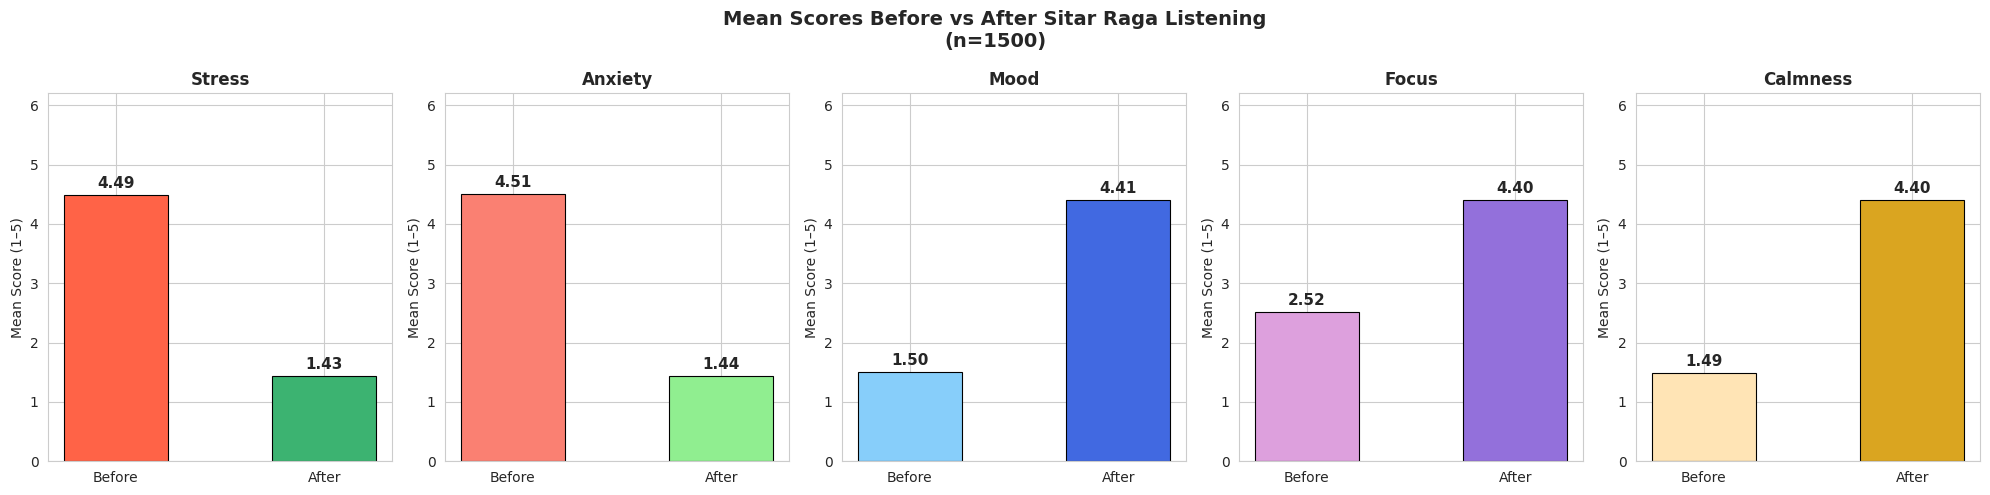

✅ Figure 1 saved.


In [ ]:
# ── Figure 1: Pre vs Post Mean Scores ─────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Mean Scores Before vs After Sitar Raga Listening\n(n=1500)', fontsize=14, fontweight='bold')

metrics = [
    ('Stress',   'Stress_Before',   'Stress_After',   'tomato',      'mediumseagreen'),
    ('Anxiety',  'Anxiety_Before',  'Anxiety_After',  'salmon',      'lightgreen'),
    ('Mood',     'Mood_Before',     'Mood_After',     'lightskyblue','royalblue'),
    ('Focus',    'Focus_Before',    'Focus_After',    'plum',        'mediumpurple'),
    ('Calmness', 'Calmness_Before', 'Calmness_After', 'moccasin',    'goldenrod'),
]
for ax, (title, bc, ac, c1, c2) in zip(axes, metrics):
    means = [df[bc].mean(), df[ac].mean()]
    bars  = ax.bar(['Before', 'After'], means, color=[c1, c2], width=0.5, edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylim(0, 6.2)
    ax.set_ylabel('Mean Score (1–5)')
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.12,
                f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/outputs/fig1_pre_post_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 saved.')

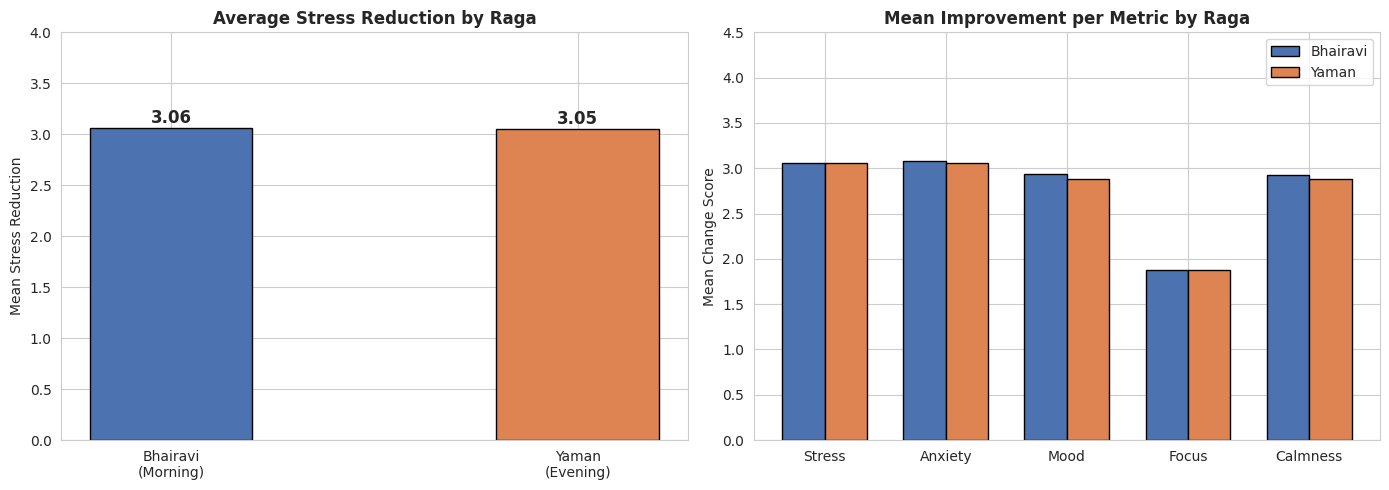

✅ Figure 2 saved.


In [ ]:
# ── Figure 2: Raga-wise Stress Reduction ──────────────────
palette = {'Raga Bhairavi (Morning)': '#4C72B0', 'Raga Yaman (Evening)': '#DD8452'}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stress reduction by raga
raga_stress = df.groupby('Raga_Listened')['Stress_Reduction'].mean()
bars = axes[0].bar(raga_stress.index, raga_stress.values,
                   color=[palette[r] for r in raga_stress.index],
                   width=0.4, edgecolor='black')
axes[0].set_title('Average Stress Reduction by Raga', fontweight='bold')
axes[0].set_ylabel('Mean Stress Reduction'); axes[0].set_ylim(0, 4)
axes[0].set_xticklabels(['Bhairavi\n(Morning)', 'Yaman\n(Evening)'])
for bar, val in zip(bars, raga_stress.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                 f'{val:.2f}', ha='center', fontsize=12, fontweight='bold')

# All reductions side by side
reduction_cols = ['Stress_Reduction','Anxiety_Reduction','Mood_Improvement',
                  'Focus_Improvement','Calmness_Improvement']
labels = ['Stress','Anxiety','Mood','Focus','Calmness']
x = np.arange(len(labels)); w = 0.35
b_vals = [df[df['Raga_Listened']=='Raga Bhairavi (Morning)'][c].mean() for c in reduction_cols]
y_vals = [df[df['Raga_Listened']=='Raga Yaman (Evening)'][c].mean()    for c in reduction_cols]
axes[1].bar(x-w/2, b_vals, w, label='Bhairavi', color='#4C72B0', edgecolor='black')
axes[1].bar(x+w/2, y_vals, w, label='Yaman',    color='#DD8452', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_title('Mean Improvement per Metric by Raga', fontweight='bold')
axes[1].set_ylabel('Mean Change Score'); axes[1].legend(); axes[1].set_ylim(0, 4.5)

plt.tight_layout()
plt.savefig('/content/outputs/fig2_raga_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 saved.')

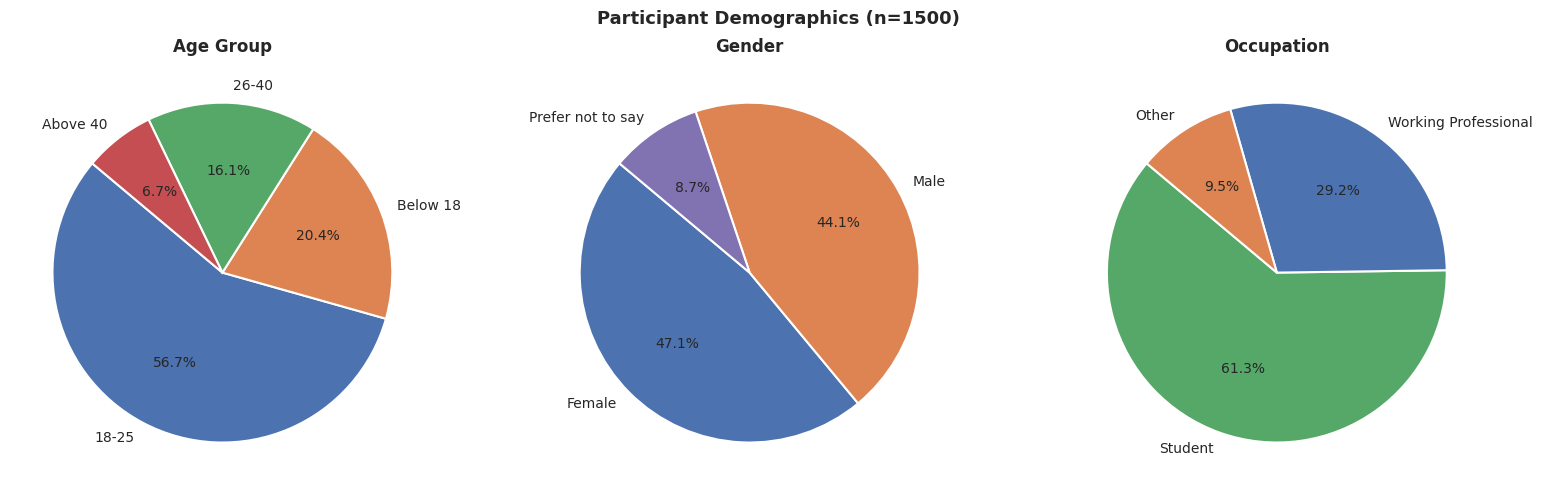

✅ Figure 3 saved.


In [ ]:
# ── Figure 3: Demographic Distribution ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Participant Demographics (n=1500)', fontsize=13, fontweight='bold')

demo_cols = [('Age_Group','Age Group'),('Gender','Gender'),('Occupation','Occupation')]
colors_demo = [['#4C72B0','#DD8452','#55A868','#C44E52'],
               ['#4C72B0','#DD8452','#8172B2'],
               ['#55A868','#4C72B0','#DD8452']]
for ax, (col, title), clrs in zip(axes, demo_cols, colors_demo):
    counts = df[col].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=clrs[:len(counts)], startangle=140,
           wedgeprops={'edgecolor':'white','linewidth':1.5})
    ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/outputs/fig3_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 saved.')

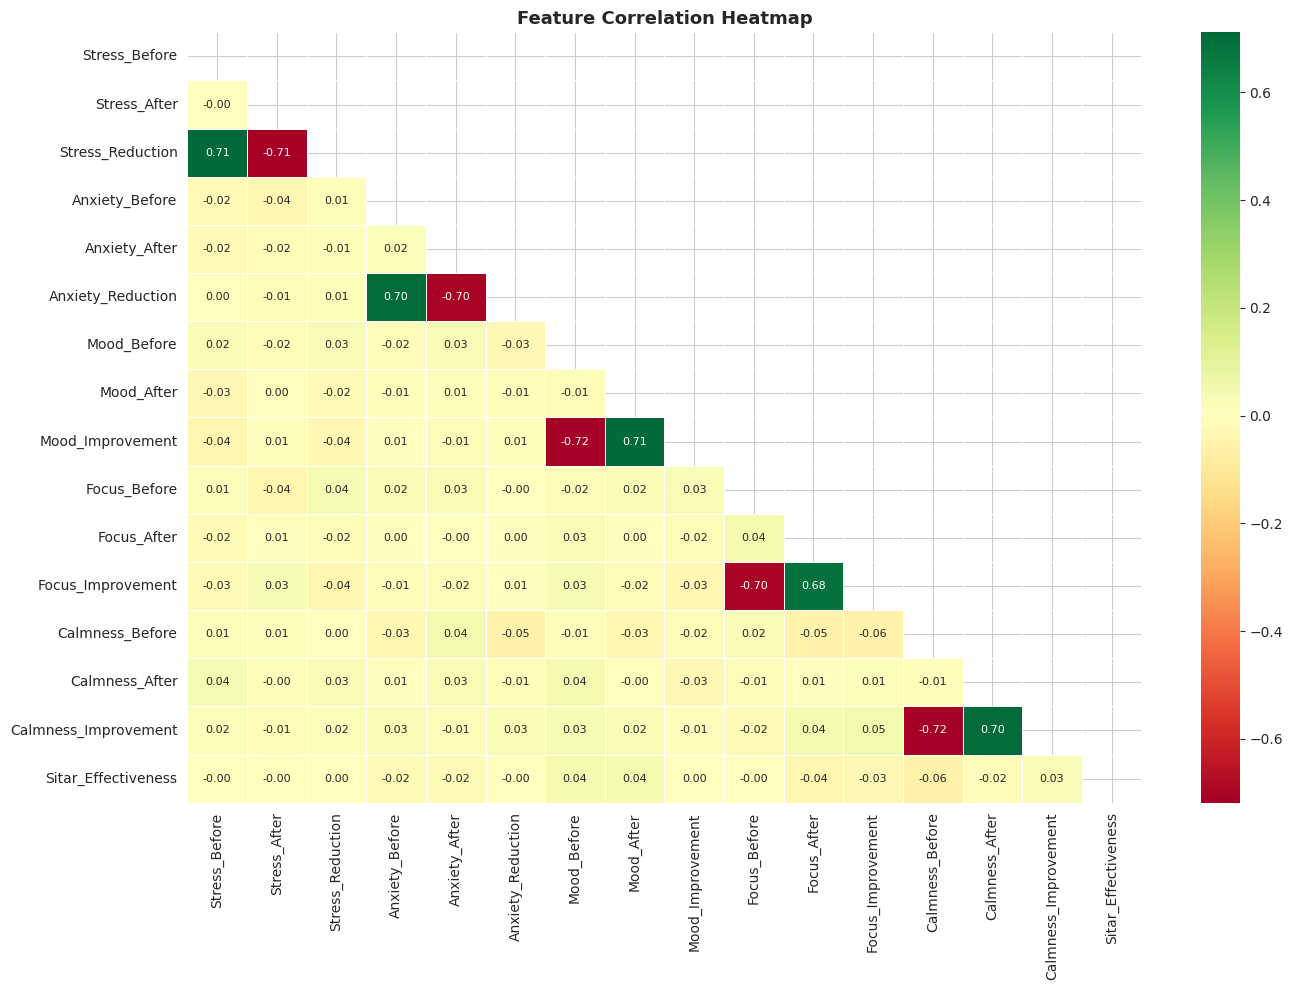

✅ Figure 4 saved.


In [ ]:
# ── Figure 4: Correlation Heatmap ─────────────────────────
num_cols = ['Stress_Before','Stress_After','Stress_Reduction',
            'Anxiety_Before','Anxiety_After','Anxiety_Reduction',
            'Mood_Before','Mood_After','Mood_Improvement',
            'Focus_Before','Focus_After','Focus_Improvement',
            'Calmness_Before','Calmness_After','Calmness_Improvement',
            'Sitar_Effectiveness']
fig, ax = plt.subplots(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size':8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 4 saved.')

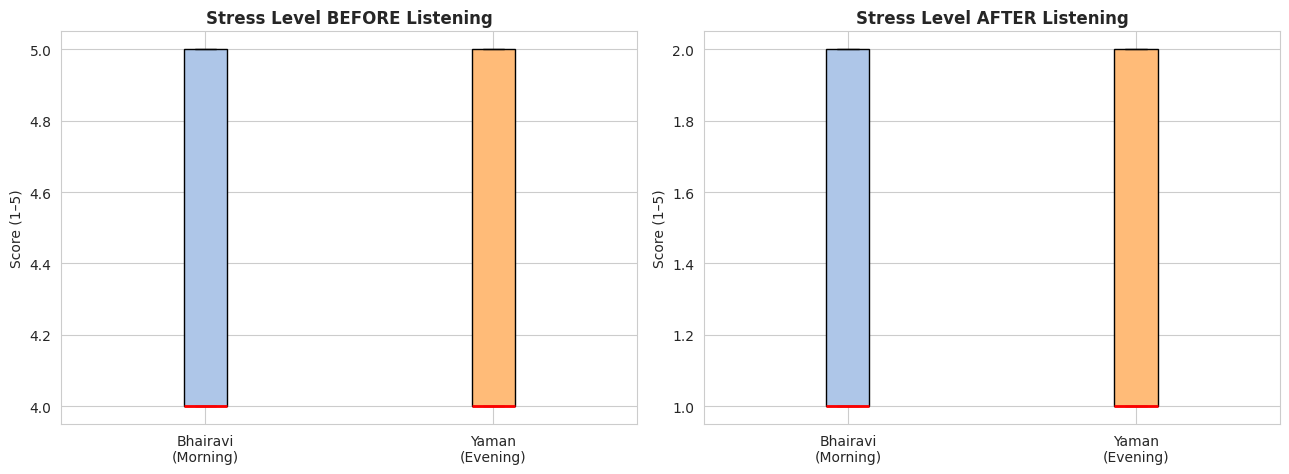

✅ Figure 5 saved.


In [ ]:
# ── Figure 5: Boxplots — Stress Before/After by Raga ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes,
    ['Stress_Before','Stress_After'],
    ['Stress Level BEFORE Listening','Stress Level AFTER Listening']):
    data_b = df[df['Raga_Listened']=='Raga Bhairavi (Morning)'][col]
    data_y = df[df['Raga_Listened']=='Raga Yaman (Evening)'][col]
    bp = ax.boxplot([data_b, data_y], patch_artist=True,
                    medianprops=dict(color='red', linewidth=2))
    bp['boxes'][0].set_facecolor('#AEC6E8')
    bp['boxes'][1].set_facecolor('#FFBB78')
    ax.set_xticklabels(['Bhairavi\n(Morning)', 'Yaman\n(Evening)'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score (1–5)')
fig.suptitle('')
plt.tight_layout()
plt.savefig('/content/outputs/fig5_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 5 saved.')

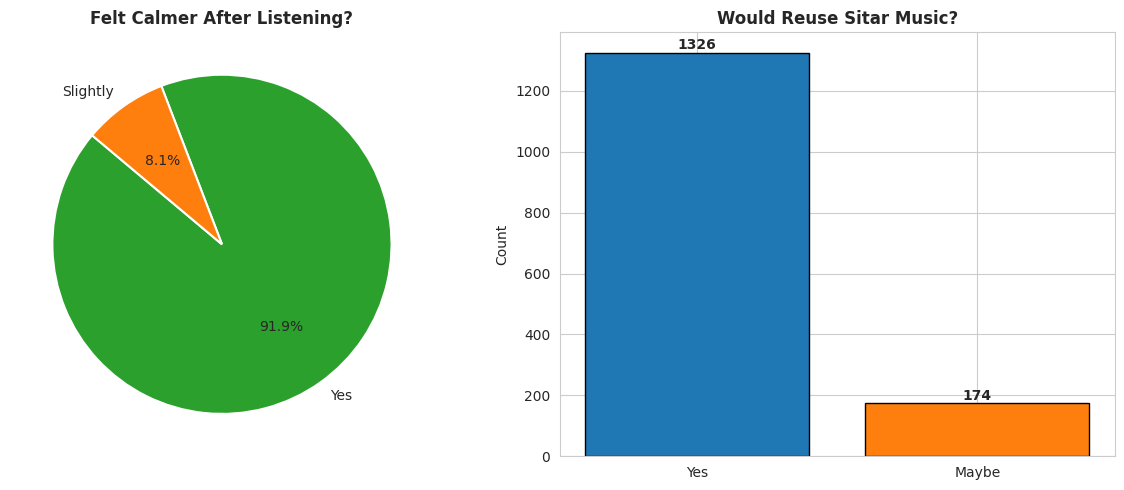

✅ Figure 6 saved.


In [ ]:
# ── Figure 6: Perceived Calm & Reuse ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

calm_counts = df['Felt_Calmer_After'].value_counts()
axes[0].pie(calm_counts.values, labels=calm_counts.index,
            autopct='%1.1f%%', colors=['#2ca02c','#ff7f0e','#d62728'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Felt Calmer After Listening?', fontweight='bold')

reuse_counts = df['Would_Reuse_Sitar'].value_counts()
colors_r = ['#1f77b4','#ff7f0e','#d62728']
axes[1].bar(reuse_counts.index, reuse_counts.values,
            color=colors_r[:len(reuse_counts)], edgecolor='black')
axes[1].set_title('Would Reuse Sitar Music?', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (label, val) in enumerate(reuse_counts.items()):
    axes[1].text(i, val+10, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/outputs/fig6_calm_reuse.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 6 saved.')

In [ ]:


TEST_PAIRS = [
    ('Stress',   'Stress_Before',   'Stress_After',   'decrease'),
    ('Anxiety',  'Anxiety_Before',  'Anxiety_After',  'decrease'),
    ('Mood',     'Mood_Before',     'Mood_After',     'increase'),
    ('Focus',    'Focus_Before',    'Focus_After',    'increase'),
    ('Calmness', 'Calmness_Before', 'Calmness_After', 'increase'),
]

def cohen_d(before, after):
    diff = np.array(before) - np.array(after)
    return round(np.mean(diff) / np.std(diff, ddof=1), 4)

def effect_label(d):
    d = abs(d)
    if d >= 0.8: return 'Large'
    if d >= 0.5: return 'Medium'
    if d >= 0.2: return 'Small'
    return 'Negligible'

def run_ttest(data, label):
    rows = []
    print(f'\n{"+"*76}')
    print(f'  Paired t-Test — {label}  (n={len(data)})')
    print(f'{"+"*76}')
    print(f'{"Metric":<12} {"M Before":>9} {"M After":>9} {"Change":>8} {"t-stat":>8} {"p-value":>10} {"Sig":>5} {"Cohen d":>9} {"Effect":>10}')
    print('-'*76)
    for metric, cb, ca, direction in TEST_PAIRS:
        b = data[cb].values; a = data[ca].values
        t_stat, p_val = ttest_rel(b, a)
        d   = cohen_d(b, a)
        sig = '✅' if p_val < 0.05 else '❌'
        chg = np.mean(b) - np.mean(a)
        print(f'{metric:<12} {np.mean(b):>9.3f} {np.mean(a):>9.3f} {chg:>8.3f} '
              f'{t_stat:>8.3f} {p_val:>10.6f} {sig:>5} {d:>9.4f} {effect_label(d):>10}')
        rows.append({'Group':label,'Metric':metric,'Direction':direction,
                     'Mean_Before':round(np.mean(b),3),'Mean_After':round(np.mean(a),3),
                     'Mean_Change':round(chg,3),
                     't_statistic':round(t_stat,4),'p_value':round(p_val,8),
                     'Significant':'Yes' if p_val<0.05 else 'No',
                     'Cohens_d':d,'Effect_Size':effect_label(d)})
    print('-'*76)
    return pd.DataFrame(rows)

r_all = run_ttest(df, 'All Participants (n=1500)')
r_b   = run_ttest(df[df['Raga_Listened']=='Raga Bhairavi (Morning)'], 'Raga Bhairavi')
r_y   = run_ttest(df[df['Raga_Listened']=='Raga Yaman (Evening)'],    'Raga Yaman')

all_ttest = pd.concat([r_all, r_b, r_y], ignore_index=True)
all_ttest.to_csv('/content/outputs/paired_ttest_results.csv', index=False)
print('\n✅ Saved: paired_ttest_results.csv')
print('\n  α = 0.05  |  Effect: Small≥0.2 · Medium≥0.5 · Large≥0.8 (Cohen,1988)')


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Paired t-Test — All Participants (n=1500)  (n=1500)
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Metric        M Before   M After   Change   t-stat    p-value   Sig   Cohen d     Effect
----------------------------------------------------------------------------
Stress           4.488     1.433    3.055  167.757   0.000000     ✅    4.3315      Large
Anxiety          4.505     1.438    3.067  170.211   0.000000     ✅    4.3948      Large
Mood             1.498     4.407   -2.909 -159.546   0.000000     ✅   -4.1195      Large
Focus            2.521     4.401   -1.880 -106.368   0.000000     ✅   -2.7464      Large
Calmness         1.493     4.396   -2.903 -160.242   0.000000     ✅   -4.1374      Large
----------------------------------------------------------------------------

++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
  Paired t-Test — Raga Bh

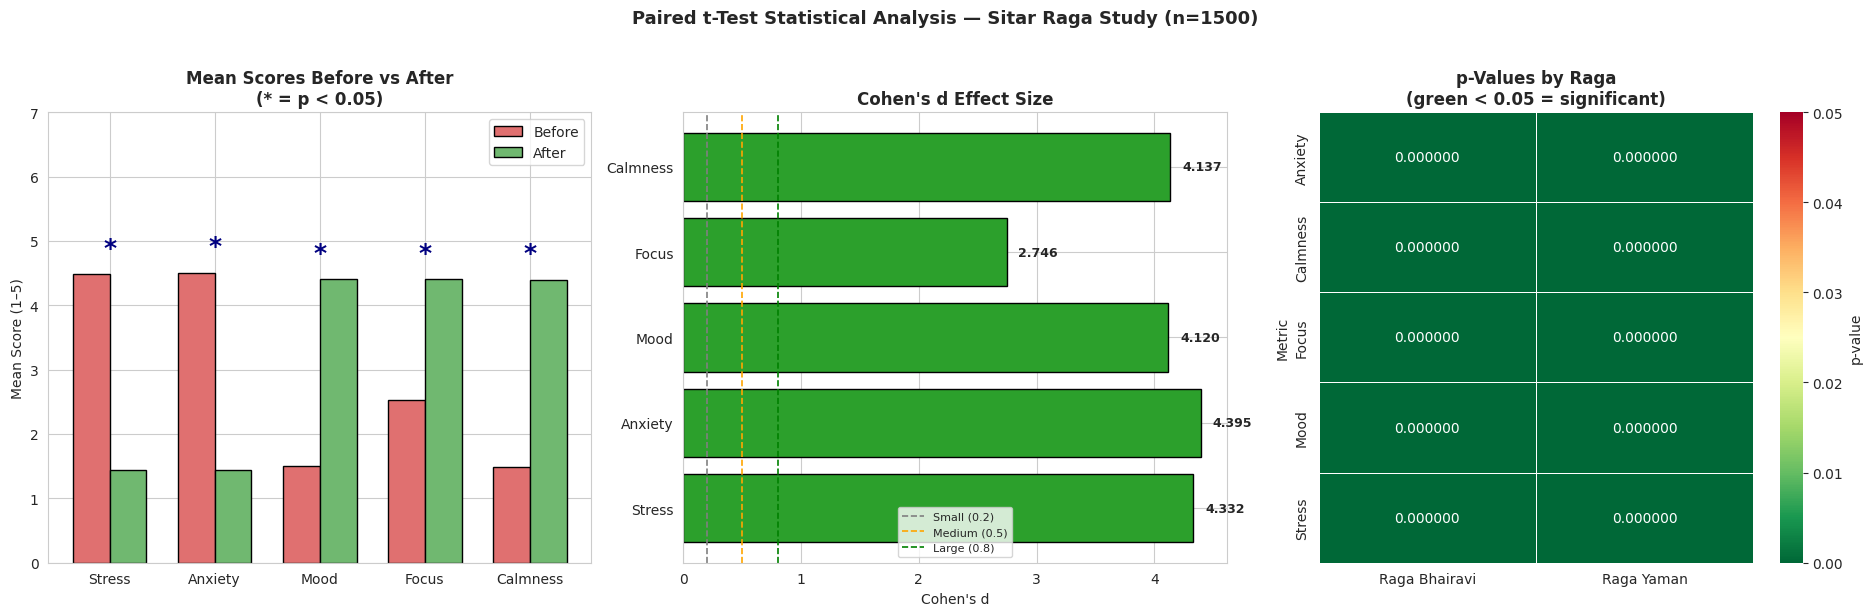

✅ Figure 7 (Paired t-Test) saved.


In [ ]:
# ── Figure 7: Paired t-Test Visualizations ────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# Panel A — Before vs After with significance stars
ax  = axes[0]
r   = r_all
x   = np.arange(len(r)); w = 0.35
ax.bar(x-w/2, r['Mean_Before'], w, label='Before', color='#E07070', edgecolor='black')
ax.bar(x+w/2, r['Mean_After'],  w, label='After',  color='#70B870', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(r['Metric'])
ax.set_title('Mean Scores Before vs After\n(* = p < 0.05)', fontweight='bold')
ax.set_ylabel('Mean Score (1–5)'); ax.set_ylim(0, 7); ax.legend()
for i, (_, row) in enumerate(r.iterrows()):
    if row['Significant'] == 'Yes':
        ax.text(i, max(row['Mean_Before'],row['Mean_After'])+0.3,
                '*', ha='center', fontsize=18, color='navy', fontweight='bold')

# Panel B — Cohen's d
ax  = axes[1]
d_v = [abs(v) for v in r['Cohens_d']]
d_c = ['#2ca02c' if v>=0.8 else '#ff7f0e' if v>=0.5 else '#1f77b4' for v in d_v]
ax.barh(r['Metric'], d_v, color=d_c, edgecolor='black')
ax.axvline(0.2, color='gray',   linestyle='--', linewidth=1.2, label='Small (0.2)')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=1.2, label='Medium (0.5)')
ax.axvline(0.8, color='green',  linestyle='--', linewidth=1.2, label='Large (0.8)')
for i, (m, v) in enumerate(zip(r['Metric'], d_v)):
    ax.text(v+0.1, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_title("Cohen's d Effect Size", fontweight='bold')
ax.set_xlabel("Cohen's d"); ax.legend(fontsize=8)

# Panel C — p-value heatmap by Raga
ax    = axes[2]
rdf   = all_ttest[all_ttest['Group'].isin(['Raga Bhairavi','Raga Yaman'])]
pivot = rdf.pivot(index='Metric', columns='Group', values='p_value')
sns.heatmap(pivot, annot=True, fmt='.6f', cmap='RdYlGn_r',
            vmin=0, vmax=0.05, ax=ax, linewidths=0.5,
            cbar_kws={'label':'p-value'})
ax.set_title('p-Values by Raga\n(green < 0.05 = significant)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Metric')

plt.suptitle('Paired t-Test Statistical Analysis — Sitar Raga Study (n=1500)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/outputs/fig7_paired_ttest.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 7 (Paired t-Test) saved.')

In [ ]:
# ── Paper-ready sentences ─────────────────────────────────
print('='*70)
print('  RESULT')
print('='*70)
for _, row in r_all.iterrows():
    changed = 'decreased' if row['Direction']=='decrease' else 'increased'
    sig_word = 'significant' if row['Significant']=='Yes' else 'non-significant'
    print(f"""
{row['Metric']}:
  A paired t-test revealed a statistically {sig_word} {changed} in
  {row['Metric'].lower()} after listening to sitar raga music
  (Before: M={row['Mean_Before']}, After: M={row['Mean_After']},
  t(1499) = {row['t_statistic']}, p = {row['p_value']},
  Cohen's d = {row['Cohens_d']}, Effect Size = {row['Effect_Size']})."""
    )

  RESULT

Stress:
  A paired t-test revealed a statistically significant decreased in
  stress after listening to sitar raga music
  (Before: M=4.488, After: M=1.433,
  t(1499) = 167.7573, p = 0.0,
  Cohen's d = 4.3315, Effect Size = Large).

Anxiety:
  A paired t-test revealed a statistically significant decreased in
  anxiety after listening to sitar raga music
  (Before: M=4.505, After: M=1.438,
  t(1499) = 170.2106, p = 0.0,
  Cohen's d = 4.3948, Effect Size = Large).

Mood:
  A paired t-test revealed a statistically significant increased in
  mood after listening to sitar raga music
  (Before: M=1.498, After: M=4.407,
  t(1499) = -159.5457, p = 0.0,
  Cohen's d = -4.1195, Effect Size = Large).

Focus:
  A paired t-test revealed a statistically significant increased in
  focus after listening to sitar raga music
  (Before: M=2.521, After: M=4.401,
  t(1499) = -106.3683, p = 0.0,
  Cohen's d = -2.7464, Effect Size = Large).

Calmness:
  A paired t-test revealed a statistically signi

In [ ]:
df2 = df.copy()

# ── Encode categoricals ───────────────────────────────────────────────────────
cat_enc = {
    'Raga_Listened':               {'Raga Bhairavi (Morning)':0,'Raga Yaman (Evening)':1},
    'Time_of_Listening':           {'Morning (4-9 AM)':0,'Evening (5-9 PM)':1},
    'Listening_Mode':              {'Headphones':0,'Speakers':1},
    'Environment':                 {'Quiet':0,'Slightly noisy':1,'Noisy':2},
    'Prior_Classical_Music_Exposure':{'Yes':2,'Occasionally':1,'No':0},
    'Gender':                      {'Male':0,'Female':1,'Prefer not to say':2},
    'Age_Group':                   {'Below 18':0,'18-25':1,'26-40':2,'Above 40':3},
    'Occupation':                  {'Student':0,'Working Professional':1,'Other':2},
    'Duration':                    {'5 minutes':0,'10 minutes':1,'15 minutes':2,'More than 15 minutes':3},
    'Felt_Calmer_After':           {'No':0,'Slightly':1,'Yes':2},
    'Would_Reuse_Sitar':           {'No':0,'Maybe':1,'Yes':2},
}
for col, mapping in cat_enc.items():
    df2[col+'_Enc'] = df2[col].map(mapping).fillna(0).astype(int)

# ── Target: Stress Label ──────────────────────────────────────────────────────
df2['Stress_Label'] = pd.cut(df2['Stress_Reduction'], bins=[-10,1,2,10],
                              labels=['Low','Medium','High'])
label_map = {'Low':0,'Medium':1,'High':2}
df2['Stress_Label_Enc'] = df2['Stress_Label'].astype(str).map(label_map)

# ── Feature matrix ────────────────────────────────────────────────────────────
FEATURE_COLS = [
    'Raga_Listened_Enc','Time_of_Listening_Enc','Listening_Mode_Enc',
    'Environment_Enc','Prior_Classical_Music_Exposure_Enc',
    'Age_Group_Enc','Gender_Enc','Occupation_Enc','Duration_Enc',
    'Stress_Before','Anxiety_Before','Mood_Before','Focus_Before','Calmness_Before',
    'Anxiety_Reduction','Mood_Improvement','Focus_Improvement','Calmness_Improvement',
    'Sitar_Effectiveness','Felt_Calmer_After_Enc','Would_Reuse_Sitar_Enc',
]

X_raw = df2[FEATURE_COLS].copy()
y     = df2['Stress_Label_Enc'].astype(int)  # cast to int for sklearn

# ── Scale: fit on train only, transform both (no data leakage) ───────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=FEATURE_COLS)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),      columns=FEATURE_COLS)

# Full scaled dataset (for cross-validation)
X = pd.DataFrame(scaler.transform(X_raw), columns=FEATURE_COLS)

# ── Save train / test splits as CSV ──────────────────────────────────────────
train_export = X_train_raw.copy()
train_export['Stress_Label']     = y_train.values
train_export['Stress_Label_Name']= y_train.map({0:'Low',1:'Medium',2:'High'}).values
train_export.to_csv('/content/outputs/train_set.csv', index=False)

test_export = X_test_raw.copy()
test_export['Stress_Label']      = y_test.values
test_export['Stress_Label_Name'] = y_test.map({0:'Low',1:'Medium',2:'High'}).values
test_export.to_csv('/content/outputs/test_set.csv', index=False)

# ── Detailed split summary ────────────────────────────────────────────────────
label_names = {0:'Low', 1:'Medium', 2:'High'}

print('='*60)
print('  TRAIN / TEST SPLIT SUMMARY')
print('='*60)
print(f'  Total samples     : {len(X_raw)}')
print(f'  Train samples     : {len(X_train)}  ({len(X_train)/len(X_raw)*100:.1f}%)')
print(f'  Test  samples     : {len(X_test)}   ({len(X_test)/len(X_raw)*100:.1f}%)')
print(f'  Features          : {len(FEATURE_COLS)}')
print(f'  Split strategy    : Stratified (random_state=42)')
print(f'  Scaler            : StandardScaler (fit on train only ✅)')
print()

print('  Class Distribution:')
print(f'  {"Label":<10} {"Total":>8} {"Train":>8} {"Test":>8}  {"Train%":>8}  {"Test%":>7}')
print('  ' + '-'*55)
for cls in [0, 1, 2]:
    total = (y == cls).sum()
    tr    = (y_train == cls).sum()
    te    = (y_test  == cls).sum()
    print(f'  {label_names[cls]:<10} {total:>8} {tr:>8} {te:>8}  {tr/len(y_train)*100:>7.1f}%  {te/len(y_test)*100:>7.1f}%')
print('  ' + '-'*55)
print(f'  {"TOTAL":<10} {len(y):>8} {len(y_train):>8} {len(y_test):>8}  {100:>7.1f}%  {100:>7.1f}%')

print()
print('  Feature Statistics (Train set — scaled):')
print(f'  {"Feature":<40} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('  ' + '-'*72)
for col in FEATURE_COLS:
    m  = X_train[col].mean()
    s  = X_train[col].std()
    mn = X_train[col].min()
    mx = X_train[col].max()
    print(f'  {col:<40} {m:>8.3f} {s:>8.3f} {mn:>8.3f} {mx:>8.3f}')

print()
print('✅ Saved: train_set.csv  &  test_set.csv  →  /content/outputs/')
print('✅ Preprocessing complete — ready for ML models.')


  TRAIN / TEST SPLIT SUMMARY
  Total samples     : 1500
  Train samples     : 1200  (80.0%)
  Test  samples     : 300   (20.0%)
  Features          : 21
  Split strategy    : Stratified (random_state=42)
  Scaler            : StandardScaler (fit on train only ✅)

  Class Distribution:
  Label         Total    Train     Test    Train%    Test%
  -------------------------------------------------------
  Low               0        0        0      0.0%      0.0%
  Medium          334      267       67     22.2%     22.3%
  High           1166      933      233     77.8%     77.7%
  -------------------------------------------------------
  TOTAL          1500     1200      300    100.0%    100.0%

  Feature Statistics (Train set — scaled):
  Feature                                      Mean      Std      Min      Max
  ------------------------------------------------------------------------
  Raga_Listened_Enc                           0.000    1.000   -1.007    0.993
  Time_of_Listening_En

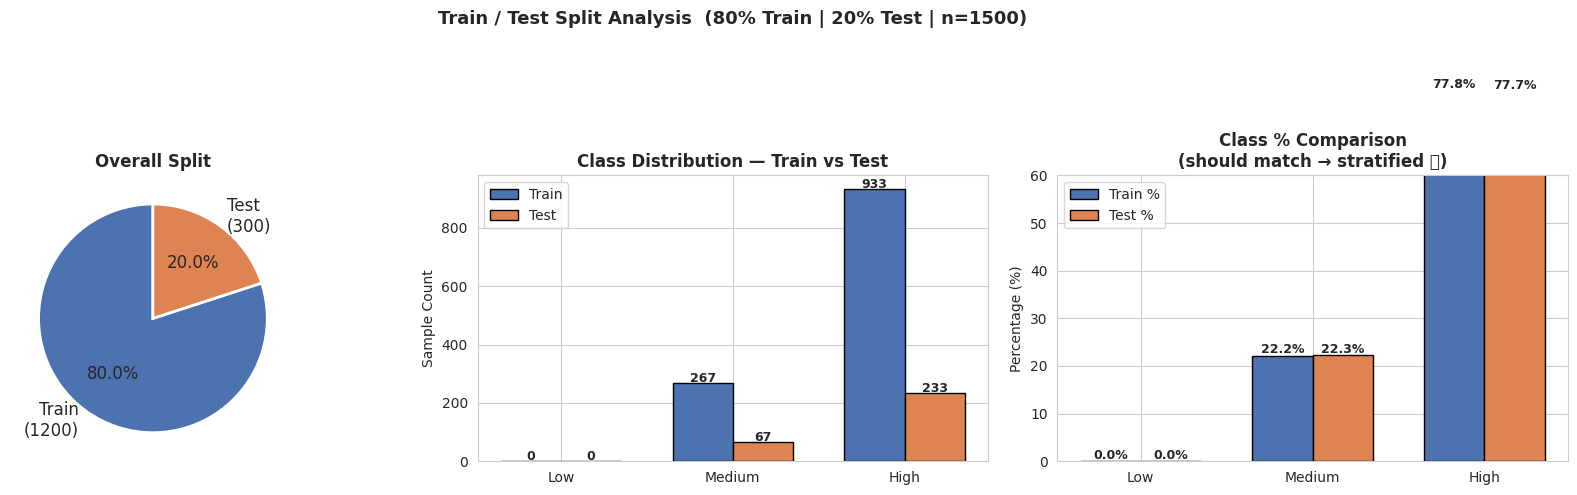

✅ Figure S1 saved: Train/Test Split Visualization.


In [ ]:
# ── Figure: Train / Test Split Visualization ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Train / Test Split Analysis  (80% Train | 20% Test | n=1500)',
             fontsize=13, fontweight='bold')

label_names_list = ['Low', 'Medium', 'High']
colors_cls = ['#4C72B0', '#DD8452', '#55A868']

# ── Panel 1: Overall split pie ───────────────────────────────────────────────
axes[0].pie([len(X_train), len(X_test)],
            labels=[f'Train\n({len(X_train)})', f'Test\n({len(X_test)})'],
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':12})
axes[0].set_title('Overall Split', fontweight='bold')

# ── Panel 2: Class distribution in Train vs Test (grouped bars) ──────────────
x   = np.arange(3); w = 0.35
tr_counts = [int((y_train==c).sum()) for c in [0,1,2]]
te_counts = [int((y_test ==c).sum()) for c in [0,1,2]]
b1 = axes[1].bar(x-w/2, tr_counts, w, label='Train', color='#4C72B0', edgecolor='black')
b2 = axes[1].bar(x+w/2, te_counts, w, label='Test',  color='#DD8452', edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(label_names_list)
axes[1].set_title('Class Distribution — Train vs Test', fontweight='bold')
axes[1].set_ylabel('Sample Count'); axes[1].legend()
for bar in list(b1)+list(b2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 str(int(bar.get_height())), ha='center', fontsize=9, fontweight='bold')

# ── Panel 3: Class % in Train vs Test (stratification check) ─────────────────
tr_pct = [round((y_train==c).sum()/len(y_train)*100,1) for c in [0,1,2]]
te_pct = [round((y_test ==c).sum()/len(y_test )*100,1) for c in [0,1,2]]
b3 = axes[2].bar(x-w/2, tr_pct, w, label='Train %', color='#4C72B0', edgecolor='black')
b4 = axes[2].bar(x+w/2, te_pct, w, label='Test %',  color='#DD8452', edgecolor='black')
axes[2].set_xticks(x); axes[2].set_xticklabels(label_names_list)
axes[2].set_title('Class % Comparison\n(should match → stratified ✅)', fontweight='bold')
axes[2].set_ylabel('Percentage (%)'); axes[2].set_ylim(0, 60); axes[2].legend()
for bar in list(b3)+list(b4):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/outputs/figS1_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure S1 saved: Train/Test Split Visualization.')


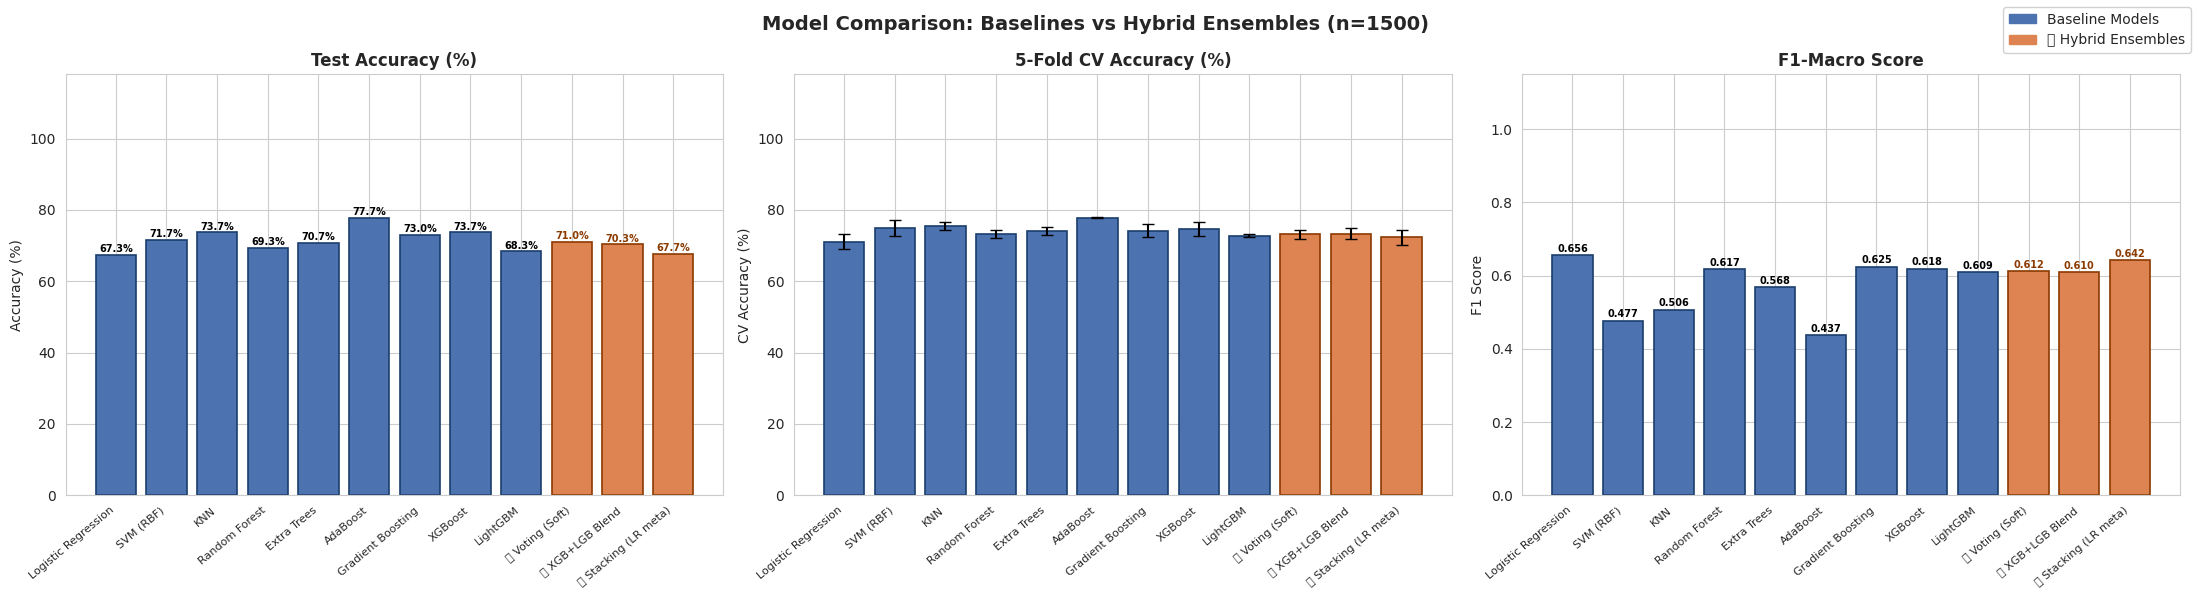

✅ Figure 8 saved.

               Model     Type  Test_Accuracy_%  CV_Mean  CV_Std  F1_Macro
            AdaBoost Baseline            77.67   0.7773  0.0013    0.4371
                 KNN Baseline            73.67   0.7547  0.0115    0.5060
             XGBoost Baseline            73.67   0.7467  0.0185    0.6184
   Gradient Boosting Baseline            73.00   0.7413  0.0178    0.6245
           SVM (RBF) Baseline            71.67   0.7493  0.0219    0.4774
     🔀 Voting (Soft)   Hybrid            71.00   0.7320  0.0129    0.6116
         Extra Trees Baseline            70.67   0.7413  0.0115    0.5679
     🔀 XGB+LGB Blend   Hybrid            70.33   0.7327  0.0155    0.6096
       Random Forest Baseline            69.33   0.7327  0.0112    0.6169
            LightGBM Baseline            68.33   0.7280  0.0050    0.6087
🔀 Stacking (LR meta)   Hybrid            67.67   0.7227  0.0204    0.6423
 Logistic Regression Baseline            67.33   0.7107  0.0213    0.6556


In [ ]:
# ── Figure 8: Model Accuracy Comparison (Baselines vs Hybrids) ───────────────
import matplotlib.patches as mpatches

names_m  = list(results.keys())
accs     = [results[n]['accuracy'] for n in names_m]
cvs      = [results[n]['cv_mean']  for n in names_m]
stds     = [results[n]['cv_std']   for n in names_m]
f1s      = [results[n]['f1_macro'] for n in names_m]
is_hybrid= ['🔀' in n for n in names_m]

# Colors: blue for baselines, orange for hybrids
bar_colors = ['#DD8452' if h else '#4C72B0' for h in is_hybrid]
edge_colors= ['#8B3A00' if h else '#1B3E6E' for h in is_hybrid]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('Model Comparison: Baselines vs Hybrid Ensembles (n=1500)',
             fontsize=14, fontweight='bold')

x = np.arange(len(names_m))

# Panel 1 — Test Accuracy
bars = axes[0].bar(x, [a*100 for a in accs], color=bar_colors,
                   edgecolor=edge_colors, linewidth=1.2)
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 118)
axes[0].set_xticks(x); axes[0].set_xticklabels(names_m, rotation=40, ha='right', fontsize=8)
for bar, val, hyb in zip(bars, accs, is_hybrid):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                 f'{val*100:.1f}%', ha='center', fontsize=7,
                 fontweight='bold', color='#8B3A00' if hyb else 'black')

# Panel 2 — CV Accuracy with error bars
bars2 = axes[1].bar(x, [c*100 for c in cvs], yerr=[s*100 for s in stds],
                    color=bar_colors, edgecolor=edge_colors, linewidth=1.2, capsize=4)
axes[1].set_title('5-Fold CV Accuracy (%)', fontweight='bold')
axes[1].set_ylabel('CV Accuracy (%)'); axes[1].set_ylim(0, 118)
axes[1].set_xticks(x); axes[1].set_xticklabels(names_m, rotation=40, ha='right', fontsize=8)

# Panel 3 — F1-Macro Score
bars3 = axes[2].bar(x, f1s, color=bar_colors, edgecolor=edge_colors, linewidth=1.2)
axes[2].set_title('F1-Macro Score', fontweight='bold')
axes[2].set_ylabel('F1 Score'); axes[2].set_ylim(0, 1.15)
axes[2].set_xticks(x); axes[2].set_xticklabels(names_m, rotation=40, ha='right', fontsize=8)
for bar, val, hyb in zip(bars3, f1s, is_hybrid):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', fontsize=7,
                 fontweight='bold', color='#8B3A00' if hyb else 'black')

# Legend
patch_base   = mpatches.Patch(color='#4C72B0', label='Baseline Models')
patch_hybrid = mpatches.Patch(color='#DD8452', label='🔀 Hybrid Ensembles')
fig.legend(handles=[patch_base, patch_hybrid], loc='upper right',
           fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('/content/outputs/fig8_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'           : names_m,
    'Type'            : ['Hybrid' if h else 'Baseline' for h in is_hybrid],
    'Test_Accuracy_%' : [round(results[n]['accuracy']*100, 2) for n in names_m],
    'CV_Mean'         : [round(results[n]['cv_mean'], 4)       for n in names_m],
    'CV_Std'          : [round(results[n]['cv_std'],  4)       for n in names_m],
    'F1_Macro'        : [round(results[n]['f1_macro'],4)       for n in names_m],
})
summary = summary.sort_values('Test_Accuracy_%', ascending=False).reset_index(drop=True)
summary.to_csv('/content/outputs/model_results_summary.csv', index=False)
print('✅ Figure 8 saved.\n')
print(summary.to_string(index=False))


In [ ]:
from sklearn.ensemble import (
    VotingClassifier, StackingClassifier,
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier, BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# ── Base estimators (tuned) ───────────────────────────────────────────────────
rf   = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2,
                               class_weight='balanced', random_state=42, n_jobs=-1)
gb   = GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                   max_depth=5, subsample=0.8, random_state=42)
xgbc = xgb.XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8, use_label_encoder=False,
                           eval_metric='mlogloss', random_state=42, n_jobs=-1)
lgbc = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.08, max_depth=6,
                            num_leaves=40, subsample=0.8, class_weight='balanced',
                            random_state=42, n_jobs=-1, verbose=-1)
et   = ExtraTreesClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                             random_state=42, n_jobs=-1)
svm  = CalibratedClassifierCV(SVC(kernel='rbf', C=5, gamma='scale',
                                   class_weight='balanced', random_state=42))
lr   = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                           solver='lbfgs', multi_class='auto', random_state=42)
knn  = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='minkowski')
ada  = AdaBoostClassifier(n_estimators=150, learning_rate=0.1, random_state=42)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HYBRID 1 — Soft Voting Ensemble (RF + XGB + LGB + ET + GB)
#  Averages predicted probabilities → more stable than hard vote
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
voting_soft = VotingClassifier(
    estimators=[('rf',rf),('xgb',xgbc),('lgb',lgbc),('et',et),('gb',gb)],
    voting='soft', weights=[2, 2, 2, 1, 1], n_jobs=-1
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HYBRID 2 — Stacking (Level-0: diverse; Level-1: Logistic Regression)
#  Level-0 learns patterns, LR meta-learner finds optimal blend
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
stacking = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=300, max_depth=12,
                                        class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                    subsample=0.8, colsample_bytree=0.8,
                                    eval_metric='mlogloss', random_state=42, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.08, max_depth=6,
                                    num_leaves=40, subsample=0.8, class_weight='balanced',
                                    random_state=42, n_jobs=-1, verbose=-1)),
        ('et',  ExtraTreesClassifier(n_estimators=200, max_depth=12,
                                      class_weight='balanced', random_state=42, n_jobs=-1)),
        ('svm', CalibratedClassifierCV(SVC(kernel='rbf', C=5, gamma='scale',
                                           class_weight='balanced', random_state=42))),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                        random_state=42),
    cv=5, passthrough=False, n_jobs=-1
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HYBRID 3 — XGB + LGB Blended (two best boosters averaged)
#  Complementary boosting strategies → reduced variance
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
xgb_lgb_blend = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                    subsample=0.85, colsample_bytree=0.85,
                                    eval_metric='mlogloss', random_state=42, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7,
                                    num_leaves=50, subsample=0.85, colsample_bytree=0.85,
                                    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)),
    ],
    voting='soft', weights=[1, 1], n_jobs=-1
)

# ── Individual baselines for comparison ──────────────────────────────────────
models = {
    # ── Baselines ─────────────────────────────────────────────────────────────
    'Logistic Regression' : lr,
    'SVM (RBF)'           : svm,
    'KNN'                 : knn,
    'Random Forest'       : rf,
    'Extra Trees'         : et,
    'AdaBoost'            : ada,
    'Gradient Boosting'   : gb,
    'XGBoost'             : xgbc,
    'LightGBM'            : lgbc,
    # ── Hybrids ───────────────────────────────────────────────────────────────
    '🔀 Voting (Soft)'    : voting_soft,
    '🔀 XGB+LGB Blend'    : xgb_lgb_blend,
    '🔀 Stacking (LR meta)': stacking,
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Re-encode y_train, y_test, and y to ensure labels are sequential starting from 0
le = LabelEncoder()
y_train_reencoded = pd.Series(le.fit_transform(y_train), index=y_train.index)
y_test_reencoded = pd.Series(le.transform(y_test), index=y_test.index)
y_reencoded_for_cv = pd.Series(le.transform(y), index=y.index)

# Update present_cls and present_names based on the re-encoded labels
present_cls = sorted(y_test_reencoded.unique().tolist()) # Should be [0, 1] if original were [1, 2]
original_label_names_map = {0:'Low', 1:'Medium', 2:'High'}
present_names = [original_label_names_map[original_label] for original_label in le.inverse_transform(present_cls)]

results = {}
print('='*80)
print(f'  {"Model":<26} {"Test Acc":>9} {"CV Mean":>9} {"CV Std":>8} {"F1-Macro":>10}')
print('='*80)

for name, model in models.items():
    # Use re-encoded y_train and y_test for fitting and evaluation
    model.fit(X_train, y_train_reencoded)
    y_pred = model.predict(X_test)

    # Ensure y_pred is also re-encoded if the model outputs original labels, but models fitted on re-encoded labels should output re-encoded predictions
    # If models predict in original (1,2) space, it should be re-encoded before comparison with y_test_reencoded
    # However, after fitting with y_train_reencoded, most models will predict in the re-encoded space.

    acc = accuracy_score(y_test_reencoded, y_pred)
    f1 = f1_score(y_test_reencoded, y_pred, average='macro')
    cv_scores = cross_val_score(model, X, y_reencoded_for_cv, cv=cv_strategy, scoring='accuracy', n_jobs=-1)
    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,
        'accuracy': acc,
        'f1_macro': f1,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
    }
    tag = '  ◀ HYBRID' if '🔀' in name else ''
    print(f'  {name:<26} {acc*100:>8.2f}%  {cv_scores.mean():>9.4f}  {cv_scores.std():>8.4f}  {f1:>10.4f}{tag}')

print('='*80)

# ── Detailed report for each hybrid ──────────────────────────────────────────
print('\n📋 Detailed Classification Reports — Hybrid Models Only:\n')
for name, res in results.items():
    if '🔀' in name:
        print(f'── {name}')
        print(classification_report(y_test_reencoded, res['y_pred'],
                                     labels=present_cls, target_names=present_names))

# ── Best overall ──────────────────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['accuracy'])
best_f1   = max(results, key=lambda k: results[k]['f1_macro'])
print(f'🏆 Best by Accuracy : {best_name}  ({results[best_name]["accuracy"]*100:.2f}%)')
print(f'🏆 Best by F1-Macro : {best_f1}   (F1={results[best_f1]["f1_macro"]:.4f})')


  Model                       Test Acc   CV Mean   CV Std   F1-Macro
  Logistic Regression           67.33%     0.7107    0.0213      0.6556
  SVM (RBF)                     71.67%     0.7493    0.0219      0.4774
  KNN                           73.67%     0.7547    0.0115      0.5060
  Random Forest                 69.33%     0.7327    0.0112      0.6169
  Extra Trees                   70.67%     0.7413    0.0115      0.5679
  AdaBoost                      77.67%     0.7773    0.0013      0.4371
  Gradient Boosting             73.00%     0.7413    0.0178      0.6245
  XGBoost                       73.67%     0.7467    0.0185      0.6184
  LightGBM                      68.33%     0.7280    0.0050      0.6087
  🔀 Voting (Soft)               71.00%     0.7320    0.0129      0.6116  ◀ HYBRID
  🔀 XGB+LGB Blend               70.33%     0.7327    0.0155      0.6096  ◀ HYBRID
  🔀 Stacking (LR meta)          67.67%     0.7227    0.0204      0.6423  ◀ HYBRID

📋 Detailed Classification Reports — 

In [ ]:
from sklearn.ensemble import (
    VotingClassifier, StackingClassifier,
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb
import lightgbm as lgb

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  LABEL RE-ENCODING  (merged from both versions)
#  Guarantees labels are sequential 0,1,2 — required by XGBoost & AdaBoost
#  Works even if pd.cut produced 1,2 or 0,1 or any non-zero-based sequence
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
le = LabelEncoder()
le.fit(y)                                                   # fit on full dataset

y_tr = pd.Series(le.transform(y_train), index=y_train.index)   # re-encoded train
y_te = pd.Series(le.transform(y_test),  index=y_test.index)    # re-encoded test
y_cv = pd.Series(le.transform(y),       index=y.index)         # re-encoded full (for CV)

# Human-readable names mapped back from original label space
_orig_name = {0:'Low', 1:'Medium', 2:'High'}
present_cls   = sorted(y_te.unique().tolist())              # e.g. [0,1,2]
present_names = [_orig_name[orig] for orig in le.inverse_transform(present_cls)]

print(f'✅ Label encoding  : {dict(zip(le.classes_, le.transform(le.classes_)))}')
print(f'   Classes present : {present_cls} → {present_names}')
print(f'   Train size      : {len(y_tr)}  |  Test size: {len(y_te)}')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  BASE ESTIMATORS  (tuned, class-balanced)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
rf   = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=2,
                               class_weight='balanced', random_state=42, n_jobs=-1)
gb   = GradientBoostingClassifier(n_estimators=200, learning_rate=0.08,
                                   max_depth=5, subsample=0.8, random_state=42)
xgbc = xgb.XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric='mlogloss', random_state=42, n_jobs=-1)
lgbc = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.08, max_depth=6,
                            num_leaves=40, subsample=0.8, class_weight='balanced',
                            random_state=42, n_jobs=-1, verbose=-1)
et   = ExtraTreesClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                             random_state=42, n_jobs=-1)
svm  = CalibratedClassifierCV(SVC(kernel='rbf', C=5, gamma='scale',
                                   class_weight='balanced', random_state=42))
lr   = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                           solver='lbfgs', multi_class='auto', random_state=42)
knn  = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='minkowski')
ada  = AdaBoostClassifier(n_estimators=150, learning_rate=0.1, random_state=42)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HYBRID 1 — Soft Voting Ensemble  (RF + XGB + LGB + ET + GB)
#  Averages predicted probabilities → more stable than hard vote
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
voting_soft = VotingClassifier(
    estimators=[('rf', rf), ('xgb', xgbc), ('lgb', lgbc), ('et', et), ('gb', gb)],
    voting='soft', weights=[2, 2, 2, 1, 1], n_jobs=-1
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HYBRID 2 — Stacking  (Level-0: RF+XGB+LGB+ET+SVM  →  Level-1: LR meta)
#  Base models learn diverse patterns; LR finds the optimal blend
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
stacking = StackingClassifier(
    estimators=[
        ('rf',  RandomForestClassifier(n_estimators=300, max_depth=12,
                                        class_weight='balanced', random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.08, max_depth=5,
                                    subsample=0.8, colsample_bytree=0.8,
                                    eval_metric='mlogloss', random_state=42, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.08, max_depth=6,
                                    num_leaves=40, subsample=0.8, class_weight='balanced',
                                    random_state=42, n_jobs=-1, verbose=-1)),
        ('et',  ExtraTreesClassifier(n_estimators=200, max_depth=12,
                                      class_weight='balanced', random_state=42, n_jobs=-1)),
        ('svm', CalibratedClassifierCV(SVC(kernel='rbf', C=5, gamma='scale',
                                           class_weight='balanced', random_state=42))),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced',
                                        random_state=42),
    cv=5, passthrough=False, n_jobs=-1
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  HYBRID 3 — XGB + LGB Blend  (two complementary boosters, soft vote)
#  XGBoost: depth-wise growth  |  LightGBM: leaf-wise growth → lower variance
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
xgb_lgb_blend = VotingClassifier(
    estimators=[
        ('xgb', xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                    subsample=0.85, colsample_bytree=0.85,
                                    eval_metric='mlogloss', random_state=42, n_jobs=-1)),
        ('lgb', lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=7,
                                    num_leaves=50, subsample=0.85, colsample_bytree=0.85,
                                    class_weight='balanced', random_state=42,
                                    n_jobs=-1, verbose=-1)),
    ],
    voting='soft', weights=[1, 1], n_jobs=-1
)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  ALL MODELS DICT  (9 baselines + 3 hybrids)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
models = {
    # Baselines
    'Logistic Regression' : lr,
    'SVM (RBF)'           : svm,
    'KNN'                 : knn,
    'Random Forest'       : rf,
    'Extra Trees'         : et,
    'AdaBoost'            : ada,
    'Gradient Boosting'   : gb,
    'XGBoost'             : xgbc,
    'LightGBM'            : lgbc,
    # Hybrids
    '🔀 Voting (Soft)'     : voting_soft,
    '🔀 XGB+LGB Blend'     : xgb_lgb_blend,
    '🔀 Stacking (LR meta)': stacking,
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results     = {}

print()
print('='*82)
print(f'  {"Model":<26} {"Test Acc":>9} {"CV Mean":>9} {"CV Std":>8} {"F1-Macro":>10}  Type')
print('='*82)

for name, model in models.items():
    # ── Train on re-encoded labels (XGBoost/AdaBoost require 0-based) ─────────
    model.fit(X_train, y_tr)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro', zero_division=0)

    # ── CV on re-encoded full dataset ─────────────────────────────────────────
    cv_scores = cross_val_score(model, X, y_cv, cv=cv_strategy,
                                 scoring='accuracy', n_jobs=-1)

    results[name] = {
        'model'   : model,
        'y_pred'  : y_pred,        # in re-encoded space
        'accuracy': acc,
        'f1_macro': f1,
        'cv_mean' : cv_scores.mean(),
        'cv_std'  : cv_scores.std(),
    }
    tag = 'HYBRID' if '🔀' in name else 'baseline'
    print(f'  {name:<26} {acc*100:>8.2f}%  {cv_scores.mean():>9.4f}  '
          f'{cv_scores.std():>8.4f}  {f1:>10.4f}  {tag}')

print('='*82)

# ── Detailed classification report — hybrids only ─────────────────────────────
print('\n📋 Detailed Reports — Hybrid Models:\n')
for name, res in results.items():
    if '🔀' in name:
        print(f'── {name}')
        print(classification_report(y_te, res['y_pred'],
                                     labels=present_cls,
                                     target_names=present_names,
                                     zero_division=0))

# ── Best model ────────────────────────────────────────────────────────────────
best_acc = max(results, key=lambda k: results[k]['accuracy'])
best_f1  = max(results, key=lambda k: results[k]['f1_macro'])
print(f'🏆 Best by Accuracy : {best_acc:<26} ({results[best_acc]["accuracy"]*100:.2f}%)')
print(f'🏆 Best by F1-Macro : {best_f1:<26} (F1={results[best_f1]["f1_macro"]:.4f})')

# Keep y_test alias for downstream cells (confusion matrix, ANN, etc.)
y_test_enc = y_te    # re-encoded test labels — use this in all cells below


✅ Label encoding  : {np.int64(1): np.int64(0), np.int64(2): np.int64(1)}
   Classes present : [0, 1] → ['Medium', 'High']
   Train size      : 1200  |  Test size: 300

  Model                       Test Acc   CV Mean   CV Std   F1-Macro  Type
  Logistic Regression           67.33%     0.7107    0.0213      0.6556  baseline
  SVM (RBF)                     71.67%     0.7493    0.0219      0.4774  baseline
  KNN                           73.67%     0.7547    0.0115      0.5060  baseline
  Random Forest                 69.33%     0.7327    0.0112      0.6169  baseline
  Extra Trees                   70.67%     0.7413    0.0115      0.5679  baseline
  AdaBoost                      77.67%     0.7773    0.0013      0.4371  baseline
  Gradient Boosting             73.00%     0.7413    0.0178      0.6245  baseline
  XGBoost                       73.67%     0.7467    0.0185      0.6184  baseline
  LightGBM                      68.33%     0.7280    0.0050      0.6087  baseline
  🔀 Voting (Soft)  

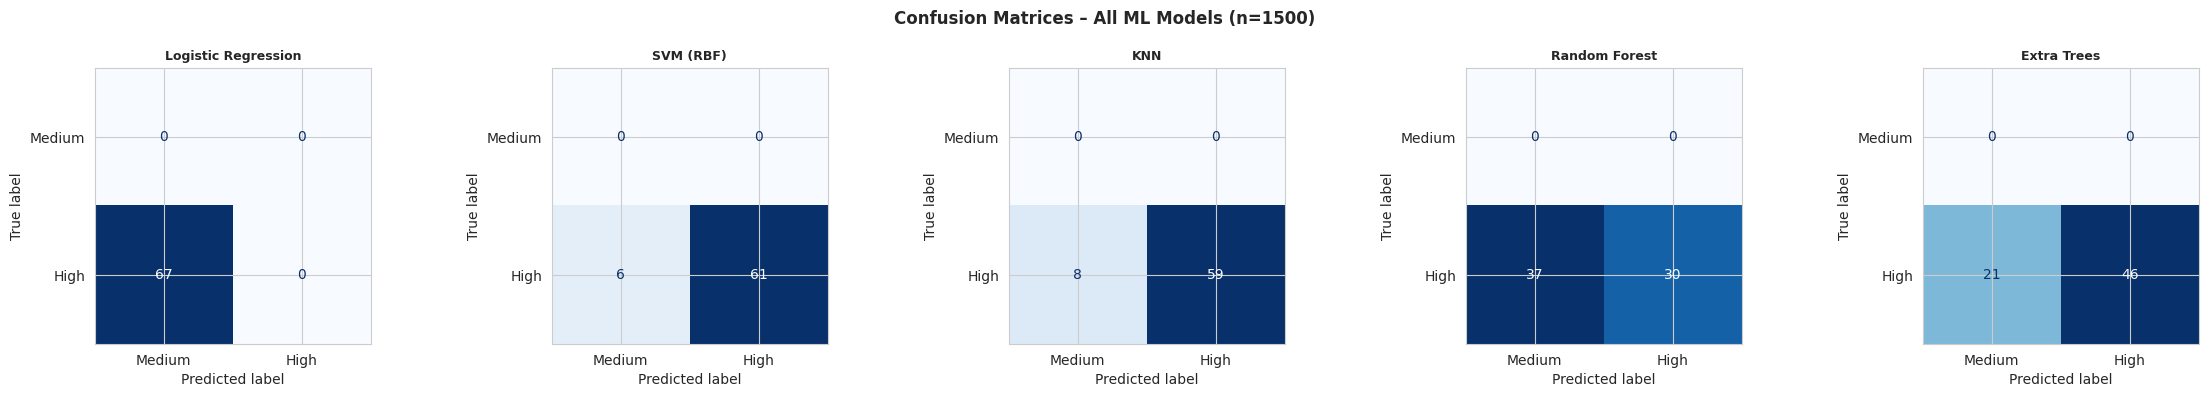

✅ Figure 9 saved.


In [ ]:
# ── Figure 9: Confusion Matrices ──────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(23, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'], labels=present_cls)
    ConfusionMatrixDisplay(cm, display_labels=present_names).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=9, fontweight='bold')
fig.suptitle('Confusion Matrices – All ML Models (n=1500)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/fig9_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 9 saved.')

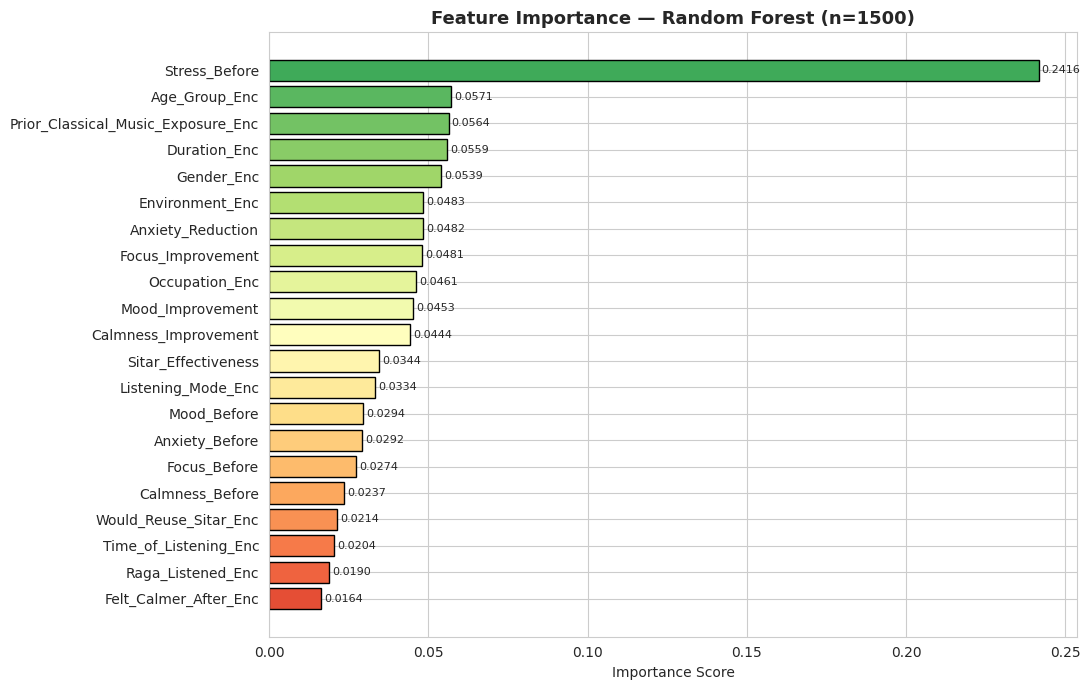

✅ Figure 10 saved.

Top 5 features:
Stress_Before                         0.241588
Age_Group_Enc                         0.057079
Prior_Classical_Music_Exposure_Enc    0.056371
Duration_Enc                          0.055911
Gender_Enc                            0.053902


In [ ]:
# ── Feature Importance ────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 7))
cmap_imp = plt.colormaps.get_cmap('RdYlGn_r') if hasattr(plt, 'colormaps') else plt.cm.RdYlGn_r
colors_imp = cmap_imp(np.linspace(0.15, 0.85, len(importances)))
ax.barh(importances.index[::-1], importances.values[::-1],
        color=colors_imp[::-1], edgecolor='black')
ax.set_title('Feature Importance — Random Forest (n=1500)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, (name, val) in enumerate(zip(importances.index[::-1], importances.values[::-1])):
    ax.text(val+0.001, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('/content/outputs/fig10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 10 saved.')
print('\nTop 5 features:')
print(importances.head(5).to_string())

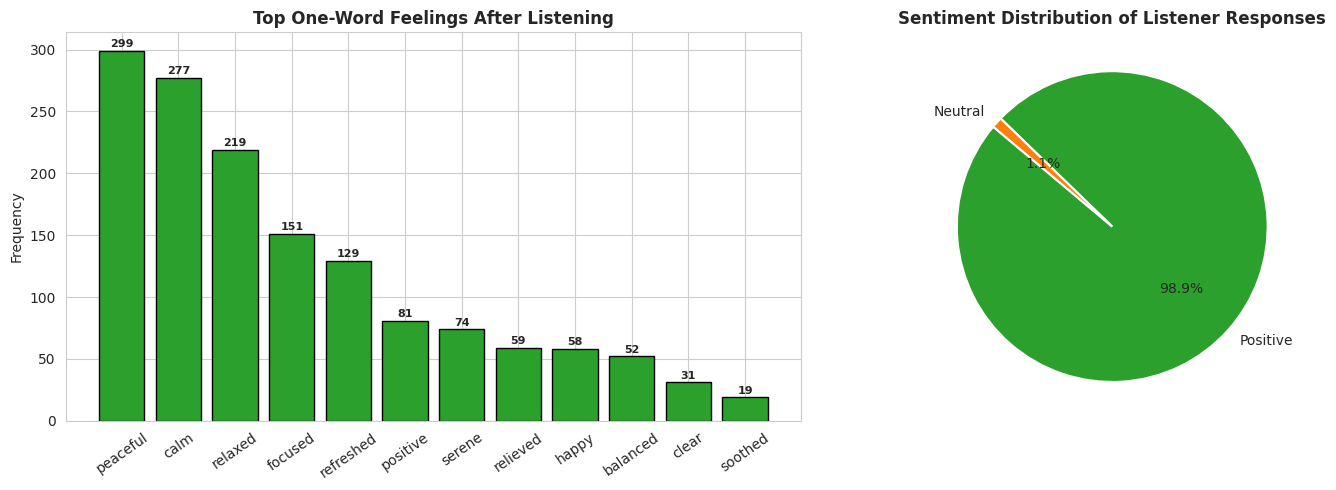

✅ Figure 11 saved.

Sentiment counts:
Sentiment
Positive    1483
Neutral       17


In [ ]:
# ── NLP Sentiment Analysis ────────────────────────────────
words = df['One_Word_Feeling'].str.lower().str.strip().tolist()
word_counts = Counter(words)

positive_words = {'calm','peaceful','relaxed','serene','refreshed','focused',
                  'positive','happy','relieved','balanced','clear','soothed',
                  'tranquil','light'}
negative_words = {'tense','anxious','tired','distracted','bored','stressed'}

def get_sentiment(w):
    if w in positive_words: return 'Positive'
    if w in negative_words: return 'Negative'
    return 'Neutral'

df['Sentiment'] = df['One_Word_Feeling'].str.lower().str.strip().apply(get_sentiment)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
wc_df = pd.Series(word_counts).sort_values(ascending=False).head(12)
bar_colors = ['#2ca02c' if get_sentiment(w)=='Positive'
              else '#d62728' if get_sentiment(w)=='Negative'
              else '#ff7f0e' for w in wc_df.index]
axes[0].bar(wc_df.index, wc_df.values, color=bar_colors, edgecolor='black')
axes[0].set_title('Top One-Word Feelings After Listening', fontweight='bold')
axes[0].set_ylabel('Frequency'); axes[0].tick_params(axis='x', rotation=35)
for i, val in enumerate(wc_df.values):
    axes[0].text(i, val+3, str(val), ha='center', fontsize=8, fontweight='bold')

sent_counts = df['Sentiment'].value_counts()
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            autopct='%1.1f%%', colors=['#2ca02c','#ff7f0e','#d62728'],
            startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Sentiment Distribution of Listener Responses', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/fig11_nlp_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 11 saved.')
print(f'\nSentiment counts:\n{df["Sentiment"].value_counts().to_string()}')

In [ ]:
# ── Robust class count (works even if a class is missing in train/test split) ─
# Use the re-encoded target variables from the previous step for consistency
n_classes = int(y_reencoded_for_cv.nunique())           # Recalculate based on re-encoded labels
y_train_np = np.array(y_train_reencoded, dtype=np.int32)
y_test_np  = np.array(y_test_reencoded,  dtype=np.int32)

# Validate no out-of-range labels before one-hot encoding
assert y_train_np.min() >= 0 and y_train_np.max() < n_classes,     f"Train labels out of range [0, {n_classes}): min={y_train_np.min()}, max={y_train_np.max()}"
assert y_test_np.min()  >= 0 and y_test_np.max()  < n_classes,     f"Test labels out of range [0, {n_classes}): min={y_test_np.min()},  max={y_test_np.max()}"

y_train_cat = to_categorical(y_train_np, num_classes=n_classes)
y_test_cat  = to_categorical(y_test_np,  num_classes=n_classes)

# Adjust the print statement to reflect the actual labels being used
print(f'✅ Classes        : {n_classes}  {list(range(n_classes))} → {present_names}')
print(f'   y_train_cat   : {y_train_cat.shape}')
print(f'   y_test_cat    : {y_test_cat.shape}')

# ── Reproducibility ───────────────────────────────────────────────────────────
import random
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# ── ANN Architecture ──────────────────────────────────────────────────────────
n_features = X_train.shape[1]          # use X_train, not X (avoids shape mismatch)

ann_model = Sequential([
    tf.keras.Input(shape=(n_features,)),
    Dense(256, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.3),
    Dense(128, activation='relu',
          kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    BatchNormalization(), Dropout(0.2),
    Dense(64,  activation='relu'), Dropout(0.1),
    Dense(32,  activation='relu'),
    Dense(n_classes, activation='softmax'),
], name='Sitar_Raga_ANN')

ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
ann_model.summary()

✅ Classes        : 2  [0, 1] → ['Medium', 'High']
   y_train_cat   : (1200, 2)
   y_test_cat    : (300, 2)


Model: "Sitar_Raga_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,466 (197.13 KB)

 Trainable params: 49,698 (194.13 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5),
]
history = ann_model.fit(
    X_train, y_train_cat, validation_split=0.2,
    epochs=200, batch_size=32, callbacks=callbacks, verbose=1)

_, test_acc = ann_model.evaluate(X_test, y_test_cat, verbose=0)
y_pred_ann  = np.argmax(ann_model.predict(X_test), axis=1)
print(f'\n🏆 ANN Test Accuracy: {test_acc*100:.2f}%')
print(classification_report(y_test, y_pred_ann, labels=present_cls, target_names=present_names))

Epoch 1/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7260 - loss: 0.5953 - val_accuracy: 0.7833 - val_loss: 0.5700 - learning_rate: 0.0010
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7781 - loss: 0.4478 - val_accuracy: 0.7833 - val_loss: 0.5146 - learning_rate: 0.0010
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8208 - loss: 0.3701 - val_accuracy: 0.7625 - val_loss: 0.4620 - learning_rate: 0.0010
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8302 - loss: 0.3530 - val_accuracy: 0.7333 - val_loss: 0.4325 - learning_rate: 0.0010
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8490 - loss: 0.3371 - val_accuracy: 0.7417 - val_loss: 0.4152 - learning_rate: 0.0010
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8510 - loss: 0.3099 - val_accuracy: 0.7333 - val_loss: 0.4118 - learning_rate: 0.0010
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8687 - loss: 0.2815 - val_ac

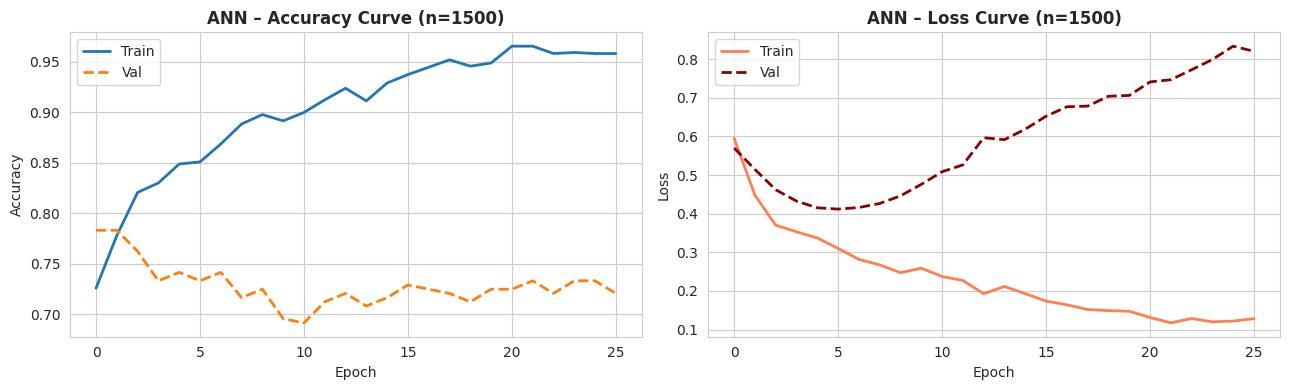

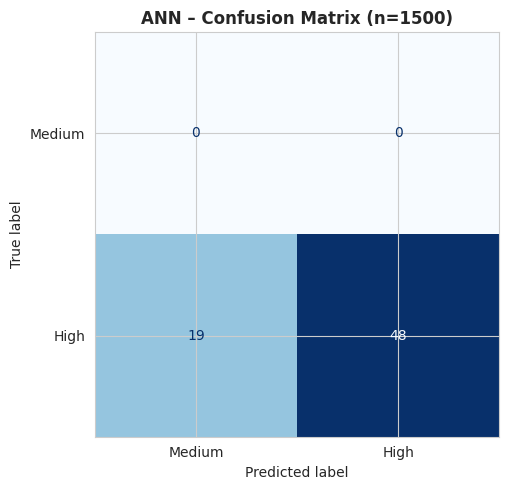

✅ Figures 12 & 13 saved.


In [ ]:
# ── Figure 12: ANN Training Curves ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
axes[0].plot(history.history[acc_key],     label='Train', linewidth=2)
axes[0].plot(history.history[val_acc_key], label='Val',   linewidth=2, linestyle='--')
axes[0].set_title('ANN – Accuracy Curve (n=1500)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train', linewidth=2, color='coral')
axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2, linestyle='--', color='darkred')
axes[1].set_title('ANN – Loss Curve (n=1500)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout()
plt.savefig('/content/outputs/fig12_ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 13: ANN Confusion Matrix ──────────────────────
fig, ax = plt.subplots(figsize=(6, 5))
cm_ann = confusion_matrix(y_test, y_pred_ann, labels=present_cls)
ConfusionMatrixDisplay(cm_ann, display_labels=present_names).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('ANN – Confusion Matrix (n=1500)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/fig13_ann_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figures 12 & 13 saved.')

In [ ]:
print('='*65)
print('  FINAL RESULTS SUMMARY — Sitar Raga Study (n=1500)')
print('='*65)

final = pd.DataFrame({
    'Model': names_m + ['ANN (Deep Learning)'],
    'Test_Accuracy_%': [round(results[n]['accuracy']*100,2) for n in names_m] + [round(test_acc*100,2)],
    'CV_Mean': [round(results[n]['cv_mean'],4) for n in names_m] + [None],
})
final = final.sort_values('Test_Accuracy_%', ascending=False).reset_index(drop=True)
final.to_csv('/content/outputs/final_results_summary.csv', index=False)
print(final.to_string(index=False))

print('\n📊 Paired t-Test Summary (All Participants):')
print(r_all[['Metric','Mean_Before','Mean_After','Mean_Change',
              't_statistic','p_value','Significant','Cohens_d','Effect_Size']].to_string(index=False))

print('\n📊 Dataset Stats:')
print(f'   Total participants      : {len(df)}')
print(f'   Raga Bhairavi listeners : {(df["Raga_Listened"]=="Raga Bhairavi (Morning)").sum()}')
print(f'   Raga Yaman listeners    : {(df["Raga_Listened"]=="Raga Yaman (Evening)").sum()}')
print(f'   Avg Stress Before       : {df["Stress_Before"].mean():.2f}')
print(f'   Avg Stress After        : {df["Stress_After"].mean():.2f}')
print(f'   Avg Stress Reduction    : {df["Stress_Reduction"].mean():.2f}')
print(f'   Positive Sentiment      : {(df["Sentiment"]=="Positive").sum()} / {len(df)}')
print(f'   Felt Calmer (Yes)       : {(df["Felt_Calmer_After"]=="Yes").sum()} / {len(df)}')

  FINAL RESULTS SUMMARY — Sitar Raga Study (n=1500)
               Model  Test_Accuracy_%  CV_Mean
            AdaBoost            77.67   0.7773
             XGBoost            73.67   0.7467
 ANN (Deep Learning)            73.67      NaN
                 KNN            73.67   0.7547
   Gradient Boosting            73.00   0.7413
           SVM (RBF)            71.67   0.7493
     🔀 Voting (Soft)            71.00   0.7320
         Extra Trees            70.67   0.7413
     🔀 XGB+LGB Blend            70.33   0.7327
       Random Forest            69.33   0.7327
            LightGBM            68.33   0.7280
🔀 Stacking (LR meta)            67.67   0.7227
 Logistic Regression            67.33   0.7107

📊 Paired t-Test Summary (All Participants):
  Metric  Mean_Before  Mean_After  Mean_Change  t_statistic  p_value Significant  Cohens_d Effect_Size
  Stress        4.488       1.433        3.055     167.7573      0.0         Yes    4.3315       Large
 Anxiety        4.505       1.438      

In [ ]:
# ── Download all outputs as ZIP ───────────────────────────
import shutil
shutil.make_archive('/content/Sitar_Raga_Full_Results', 'zip', '/content/outputs')
from google.colab import files
files.download('/content/Sitar_Raga_Full_Results.zip')
print('✅ Downloaded: Sitar_Raga_Full_Results.zip')
print('\nFiles inside:')
for f in sorted(os.listdir('/content/outputs')):
    size = os.path.getsize(f'/content/outputs/{f}')
    print(f'   {f:50s}  ({size/1024:.1f} KB)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: Sitar_Raga_Full_Results.zip

Files inside:
   audio_features.csv                                  (1.9 KB)
   fig10_feature_importance.png                        (137.0 KB)
   fig11_nlp_sentiment.png                             (104.6 KB)
   fig12_ann_training_curves.png                       (88.2 KB)
   fig13_ann_confusion_matrix.png                      (23.7 KB)
   fig1_pre_post_comparison.png                        (61.0 KB)
   fig2_raga_comparison.png                            (71.4 KB)
   fig3_demographics.png                               (132.3 KB)
   fig4_correlation_heatmap.png                        (226.5 KB)
   fig5_boxplots.png                                   (35.3 KB)
   fig6_calm_reuse.png                                 (59.9 KB)
   fig7_paired_ttest.png                               (143.6 KB)
   fig8_model_comparison.png                           (161.9 KB)
   fig9_confusion_matrices.png                         (52.0 KB)
   figA1_waveforms.png      